# LECTURE: FINANCIAL DATA ANALYSIS WITH PYTHON - Porflolios

## PART 1: FOUNDATIONS OF TIME SERIES ANALYSIS

### 1.1: Setup and Global Imports

We will install and import all necessary libraries for the entire lecture here.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import math
import seaborn as sns
from copy import deepcopy
from IPython.display import display

import itertools
from pypfopt import risk_models, expected_returns, plotting 
from pypfopt.efficient_frontier import EfficientFrontier

id_student = 11230963
df_close = pd.read_csv('stock_close_prices.csv', index_col= 0, parse_dates= True)
np.random.seed(11230963)
assets = np.random.choice(df_close.columns, size = 5, replace = False).tolist()
print(f"Selected portfolio: {assets}")

Selected portfolio: ['XOM', 'V', 'TSLA', 'KO', 'PG']


In [3]:

class Config:
    # dataset config
    tickers = assets
    
    end_date = pd.Timestamp.today()
    years_of_data = 5
    start_date = end_date - pd.DateOffset(years=years_of_data)
    test_month = 1
    train_year = 2
    risk_free_rate = 0.02
    trading_days = 252
    csv ='stock_close_prices.csv'

    # theme config
    fig_size = (14, 7)
    theme = "darkgrid"
    dis_max_collumns = 10
    dis_width = 1000

def apply_global_settings():
    sns.set_theme(style=Config.theme)
    plt.rcParams['figure.figsize'] = Config.fig_size
    pd.set_option('display.max_columns', Config.dis_max_collumns)
    pd.set_option('display.width', Config.dis_width)
    try:
        %matplotlib inline
    except:
        pass
    print("All libraries imported and settings configures")

apply_global_settings()
print(f"Time Period: {Config.start_date.date()} -> {Config.end_date.date()}")

All libraries imported and settings configures
Time Period: 2020-12-05 -> 2025-12-05


### 1.2: Load Data for Part 1 (Introductory Data)

To learn the foundational concepts, we will load a large dataset (5 years) as an example.

In [46]:
# --- LOAD & CLEAN DATA ---

def loaddata(file_path, selected_tickers, history_years):
    print(f"\n" + "="*40)
    print(f" LOADING MARKET DATA (LAST {history_years} YEARS)")
    print(f"="*40)
    print(f"Target Tickers: {selected_tickers}")
    
    try:
        df = pd.read_csv(file_path, index_col=0, parse_dates=True)
        available = df.columns.intersection(selected_tickers)
        if len(available) == 0:
            raise ValueError("CRITICAL ERROR: No valid tickers found.")
        df = df[available]
        df = df.sort_index()
        df = df.ffill().dropna()
        if not df.empty:
            real_end_date = df.index.max()
            cutoff_date = real_end_date - pd.DateOffset(years=history_years)
            df = df.loc[df.index >= cutoff_date]
        if df.empty:
            raise ValueError("CRITICAL ERROR: Dataset empty after filtering history.")
    
        print(f"\nDATA LOADED SUCCESSFULLY.")
        print(f" > Time Period: {df.index.min().date()} -> {df.index.max().date()}")
        print(f" > Total Trading Days: {len(df)}")
        print(f" > Total Assets: {len(df.columns)}")
        return df

    except Exception as e:
        print(f"\nERROR loading data: {e}")
        return None
intro_raw_data = loaddata(
    file_path=Config.csv, 
    selected_tickers=Config.tickers,
    history_years=Config.years_of_data
)
if intro_raw_data is not None:
    display(intro_raw_data.head())


 LOADING MARKET DATA (LAST 5 YEARS)
Target Tickers: ['XOM', 'V', 'TSLA', 'KO', 'PG']

DATA LOADED SUCCESSFULLY.
 > Time Period: 2023-09-01 -> 2025-11-26
 > Total Trading Days: 562
 > Total Assets: 5


,TSLA,V,PG,KO,XOM
Date,,,,,
2023-09-01,245.009995,243.971970,145.955124,55.411255,104.929619
2023-09-05,256.489990,241.248184,143.999756,54.953468,104.938866
2023-09-06,251.919998,242.054535,143.716354,54.916088,105.844704
2023-09-07,251.490005,243.018158,145.086090,54.495674,105.327080
2023-09-08,248.500000,243.165649,144.462601,54.495674,106.861458


### 1.3. Time Series, Timezone and Resampling

Index Type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>

 --- Timezone configuration ---
Current timezone: None
Timezone after localization: America/New_York
Viet Nam time: 2025-11-26 12:00:00+07:00

 --- Resampling ---
Resampled: 562 days -> 27 months


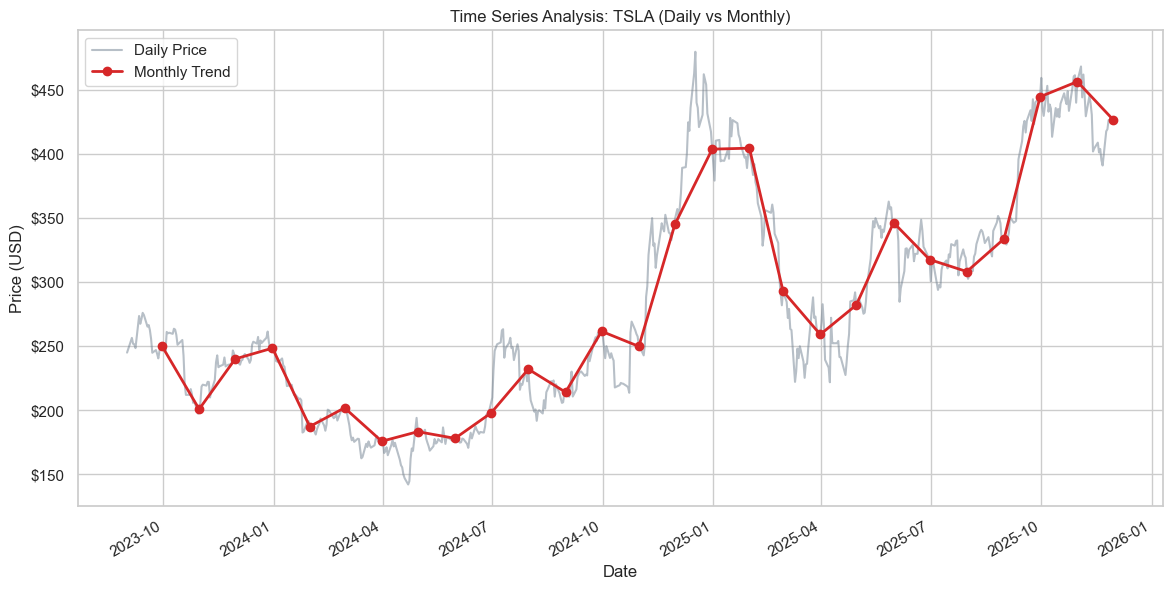

In [63]:
print(f"Index Type: {type(intro_raw_data.index)}")

def eda(data_df, ticker):
    print(f"\n --- Timezone configuration ---")
    current_tz = data_df.index.tz
    print(f"Current timezone: {current_tz}")

    if data_df.index.tz is None:
        data_df = data_df.tz_localize('America/New_York')
        print(f"Timezone after localization: {data_df.index.tz}")
    
    print(f"Viet Nam time: {data_df.index[-1].tz_convert('Asia/Ho_Chi_Minh')}")

    # Resampling
    print("\n --- Resampling ---")
    monthly_data = data_df[ticker].resample('ME').last()
    print(f"Resampled: {len(data_df)} days -> {len(monthly_data)} months")

    # Visualization
    sns.set_style("whitegrid")
    fig, ax = plt.subplots(figsize=Config.fig_size)

    data_df[ticker].plot(ax=ax, color='slategrey', alpha=0.5, label='Daily Price')
    monthly_data.plot(ax=ax, color='#d62728', marker='o', linewidth=2, label='Monthly Trend')

    ax.set(title=f"Time Series Analysis: {ticker} (Daily vs Monthly)", ylabel="Price (USD)")
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
    ax.legend()
    plt.show()

    return monthly_data

if intro_raw_data is not None:
    target_ticker = intro_raw_data.columns[0]
    test_monthly_data = eda(intro_raw_data, ticker=target_ticker)

##### Time Series & Stationarity Analysis for TSLA 
**1. Data Preprocessing:**
 
**Resampling:** The output shows data reduction from 562 days daily points to 27 monthly points. This technique filters out high-frequency noise to reveal the primary trend. 

**2. Visual Trend Analysis:**

- **Daily vs Monthly:** The grey line (Daily) exhibits significant noise and short-term volatility. The red line (Monthly Trend) smooths this out.
- **Direction:** Currently, the stock shows a fluctuate movement as the monthly price trajectory is kept raising then falling

**3. Statistical Conclusion:**

- **Non-Stationarity:** Visually, the price series does not revert to a constant mean (it trends) and the variance changes over time.
- **Inference:** Therefore, the **Price Series is Non-Stationary**. - **Next Step:** To apply statistical models or portfolio optimization (in Part 2), we must transform these prices into **Returns** to achieve stationarity.

### 1.4. Returns

- **Concept:** Returns measure the percentage change in price. This is the most important unit in finance, more so than absolute price.
- **Formula (Simple Return):**
  $R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1$
- **Tool:** `series.pct_change()`
- **Formula (Log Return):** (Useful for its additive properties)
  $r_t = \ln(\frac{P_t}{P_{t-1}}) = \ln(P_t) - \ln(P_{t-1})$
- **Tool:** `np.log(series / series.shift(1))`
- **Code (Simple Return):**

                     V  Simple_Return  Log_Return
Date                                             
2023-09-05  241.248184      -0.011164   -0.011227
2023-09-06  242.054535       0.003342    0.003337
2023-09-07  243.018158       0.003981    0.003973
2023-09-08  243.165649       0.000607    0.000607
2023-09-11  243.096817      -0.000283   -0.000283


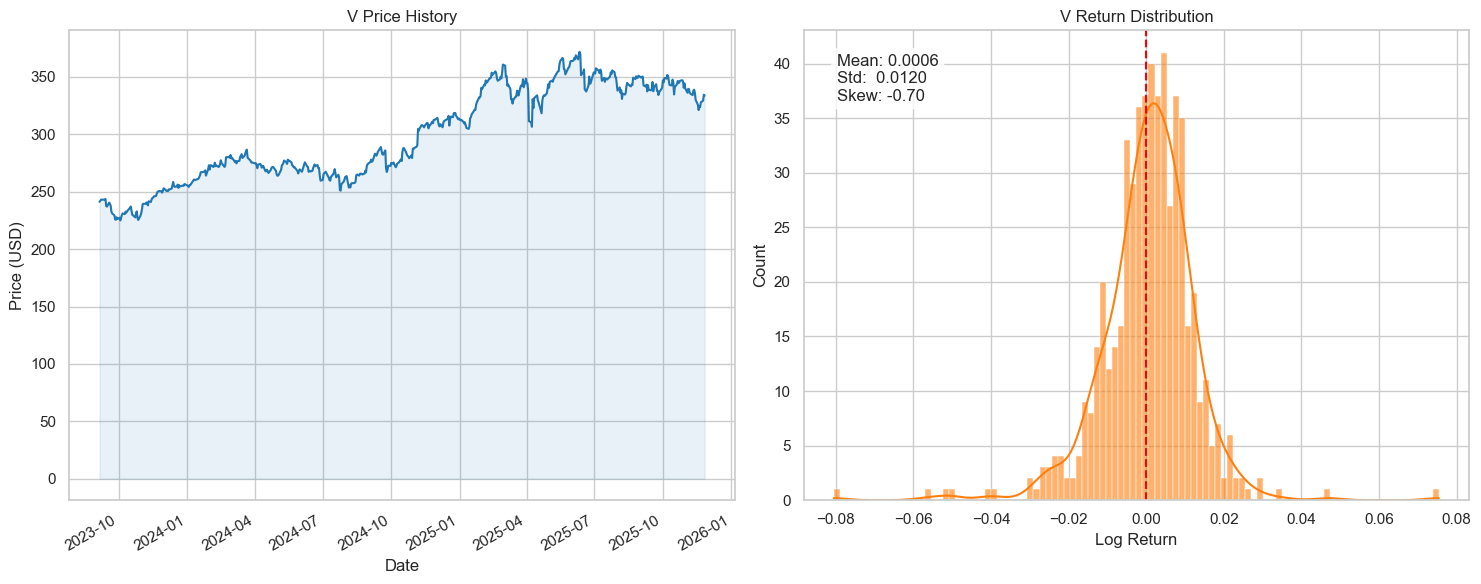

In [36]:
target_ticker = 'V'

def stock_returns(data, tickers):
    df = data[[tickers]].copy()
    df['Simple_Return'] = df[tickers].pct_change()
    df['Log_Return'] = np.log(df[tickers] / df[tickers].shift(1))
    return df.dropna()

single_stock_returns = stock_returns(intro_raw_data, target_ticker)

if single_stock_returns is not None:
    print(single_stock_returns.head())

    sns.set_style("whitegrid")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    single_stock_returns[target_ticker].plot(ax=ax1, color='#1f77b4', lw=1.5)
    ax1.fill_between(single_stock_returns.index, single_stock_returns[target_ticker], alpha=0.1, color='#1f77b4')
    ax1.set(title=f'{target_ticker} Price History', ylabel='Price (USD)')

    log_rets = single_stock_returns['Log_Return']
    sns.histplot(log_rets, bins=100, kde=True, ax=ax2, color='#ff7f0e', alpha=0.6)
    ax2.axvline(0, color='red', linestyle='--', linewidth=1.5)
    
    stats = f"Mean: {log_rets.mean():.4f}\nStd:  {log_rets.std():.4f}\nSkew: {log_rets.skew():.2f}"
    
    ax2.text(0.05, 0.95, stats, transform=ax2.transAxes, va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax2.set(title=f'{target_ticker} Return Distribution', xlabel='Log Return')

    plt.tight_layout()
    plt.show()
else:
    print("No Data Loaded")

#### **Return Distribution & Stationarity Confirmation for V**

**1. Stationarity Verification:**

• **Observation:** Unlike the raw price chart (in section 1.3), the Daily Returns histogram is centered around a mean of approximately **0**.
• **Conclusion:** The Return series shows constant mean and variance over time. It is **STATIONARY**. This confirms the data is now suitable for financial modeling (Modern Portfolio Theory) in Part 2.

**2. Risk Profile Analysis:**

• **Volatility:** The Standard Deviation (Std) is 0.0120. This represents the daily volatility.
    ◦ *(Mẹo: Nếu Std > 0.02 là biến động cao, < 0.015 là thấp).*
• **Distribution Shape:** The histogram exhibits a Normal Distribution - Very idealy.

**V Price Action vs. Returns Analysis**

**a. Price Trend Observation:**

• The "Price History" chart displays the daily closing price evolution.
• Visually, the stock exhibits a **Volatile movement** over the observed period.
• Unlike the Returns chart, the Price series does not revert to a mean, confirming its **Non-Stationary** nature.

**b. Data Transformation Logic**

• Because raw prices are non-stationary, we cannot directly use them for statistical metrics like Mean or Correlation.
• Therefore, transforming Price into **Log Returns** (as shown in the adjacent Histogram) is a necessary step to normalize the data for Portfolio Optimization in Part 2.

### 1.5. Rolling Statistics

#### 1.5.1. Simple Moving Average (SMA)

Visualizing V 50 days vs 200 days SMA


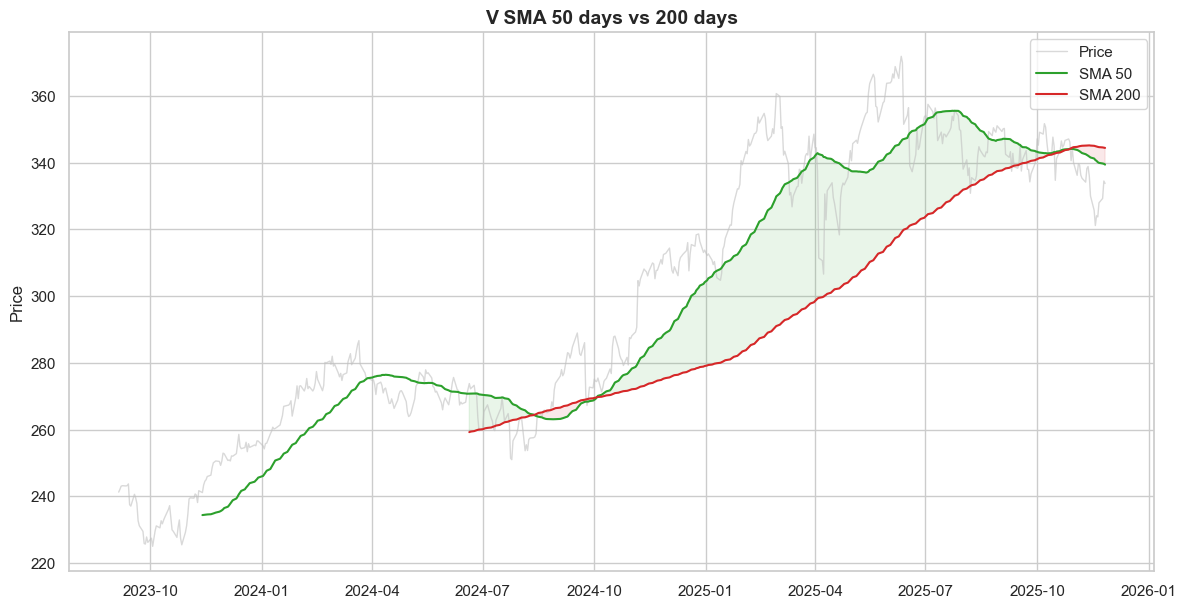

In [37]:
sma_df = single_stock_returns[[target_ticker]].copy()
sma_df['SMA50'] = sma_df[target_ticker].rolling(window=50).mean()
sma_df['SMA200'] = sma_df[target_ticker].rolling(window=200).mean()

print(f"Visualizing {target_ticker} 50 days vs 200 days SMA")

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=Config.fig_size)

ax.plot(sma_df.index, sma_df[target_ticker], label='Price', color='silver', alpha=0.6, linewidth=1)
ax.plot(sma_df.index, sma_df['SMA50'], label='SMA 50', color='#2ca02c', linewidth=1.5)
ax.plot(sma_df.index, sma_df['SMA200'], label='SMA 200', color='#d62728', linewidth=1.5)

ax.fill_between(sma_df.index, sma_df['SMA50'], sma_df['SMA200'], 
                where=(sma_df['SMA50'] >= sma_df['SMA200']), 
                color='#2ca02c', alpha=0.1, interpolate=True)

ax.fill_between(sma_df.index, sma_df['SMA50'], sma_df['SMA200'], 
                where=(sma_df['SMA50'] < sma_df['SMA200']), 
                color='#d62728', alpha=0.1, interpolate=True)

ax.set_title(f'{target_ticker} SMA 50 days vs 200 days', fontsize=14, fontweight='bold')
ax.set_ylabel('Price')
ax.legend()

plt.show()


#### **SMA 50 vs SMA 200**

**1. Trend Identification**

- The chart compares the short-term trend (SMA 50 - Green line) against the long-term trend (SMA 200 - Red line).
- Currently, the Price is trading **above** the SMA 200, indicating that the long-term trend is **Bullish (Positive)**.

**2. Crossover Signal Analysis**

- **Observation:** We observe a significant crossover event where the SMA 50 crossed **above** the SMA 200.
- **Signal Name:** In technical analysis, this is known as a **Golden Cross**. This is a strong bullish signal, suggesting potential upward momentum.



#### 1.5.2. Rolling Volatility

Visualizing V 21-day Rolling Volatility (Annualized):


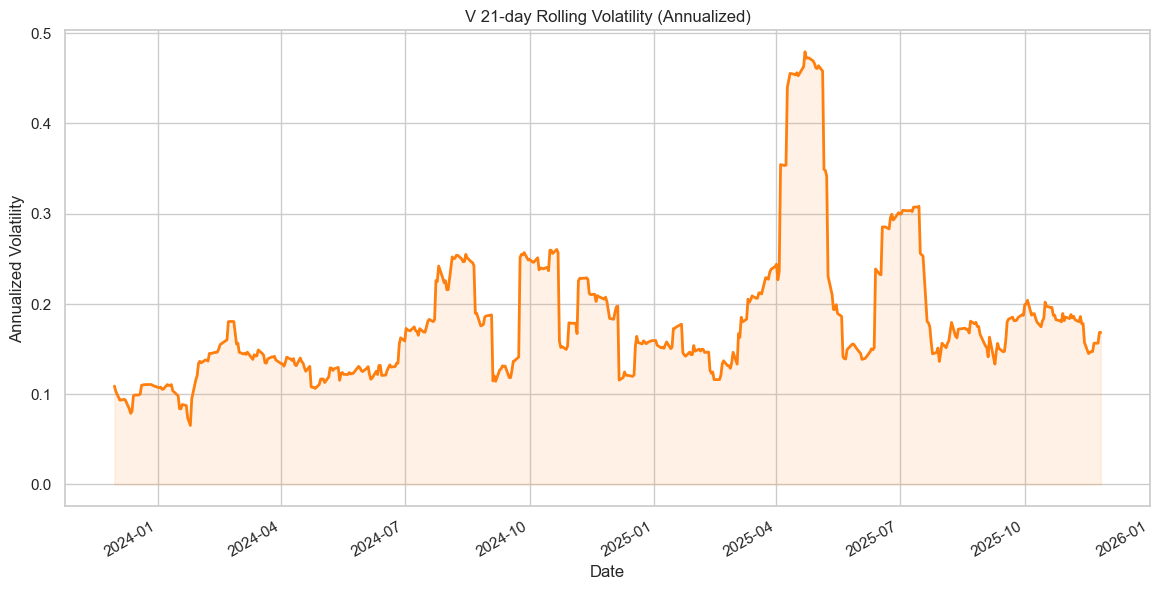

In [38]:
single_stock_returns['Volatility'] = single_stock_returns['Log_Return'].rolling(window=21).std() * np.sqrt(252)

print(f"Visualizing {target_ticker} 21-day Rolling Volatility (Annualized):")

sns.set_style("whitegrid")
subset = single_stock_returns['Volatility'].iloc[-500:]

ax = subset.plot(figsize=Config.fig_size, color='#ff7f0e', linewidth=2)
ax.fill_between(subset.index, subset, alpha=0.1, color='#ff7f0e')
ax.set(title=f'{target_ticker} 21-day Rolling Volatility (Annualized)', ylabel='Annualized Volatility')
plt.show()

#### **Rolling Volatility**

**1. Volatility Structure**

- The chart illustrates the annualized volatility over a 21-day rolling window.
- **Historical Context:** We can observe significant volatility spikes around **05/2025**, which likely correspond to major market corrections or crisis events.

**2. Current Regime Analysis** 

- Currently, the volatility level is trending **Sideways**.
- Compared to its historical average, the current risk level is considered **Moderate**.
This indicates a period of **Stability**. The market sentiment is relatively stable, supporting a Buy-and-Hold strategy.


#### 1.5.3: Heatmap


 GENERATING PORTFOLIO CORRELATION MATRIX
Correlation Matrix Head:


,TSLA,V,PG,KO,XOM
TSLA,1.000000,0.312687,-0.020770,-0.069077,0.093836
V,0.312687,1.000000,0.306314,0.298807,0.230529
PG,-0.020770,0.306314,1.000000,0.568083,0.123184
KO,-0.069077,0.298807,0.568083,1.000000,0.139453
XOM,0.093836,0.230529,0.123184,0.139453,1.000000


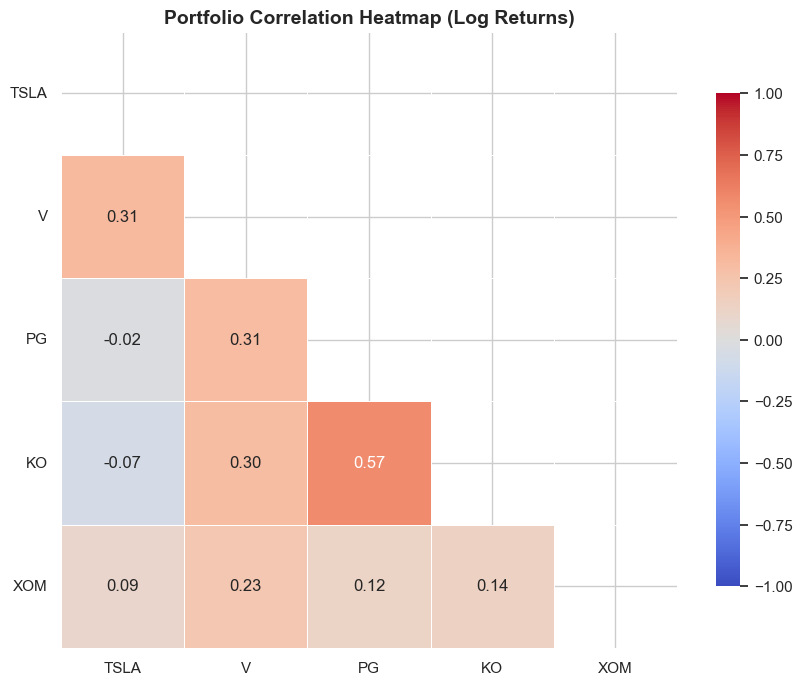

In [40]:
print(f"\n" + "="*50)
print(f" GENERATING PORTFOLIO CORRELATION MATRIX")
print(f"="*50)

all_log_returns = np.log(intro_raw_data / intro_raw_data.shift(1)).dropna()
corr_matrix = all_log_returns.corr()

print("Correlation Matrix Head:")
display(corr_matrix.head())

plt.figure(figsize=(10, 8)) 
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, 
    mask=mask,        
    annot=True,       
    fmt=".2f",          
    cmap='coolwarm',   
    vmin=-1, vmax=1,    
    linewidths=0.5,      
    square=True,         
    cbar_kws={"shrink": .8}
)
plt.title('Portfolio Correlation Heatmap (Log Returns)', fontsize=14, fontweight='bold')
plt.yticks(rotation=0) 
plt.show()

#### 1.5.4. Rolling Correlation

Visualizing 60 day Rolling Correlation: TSLA vs V


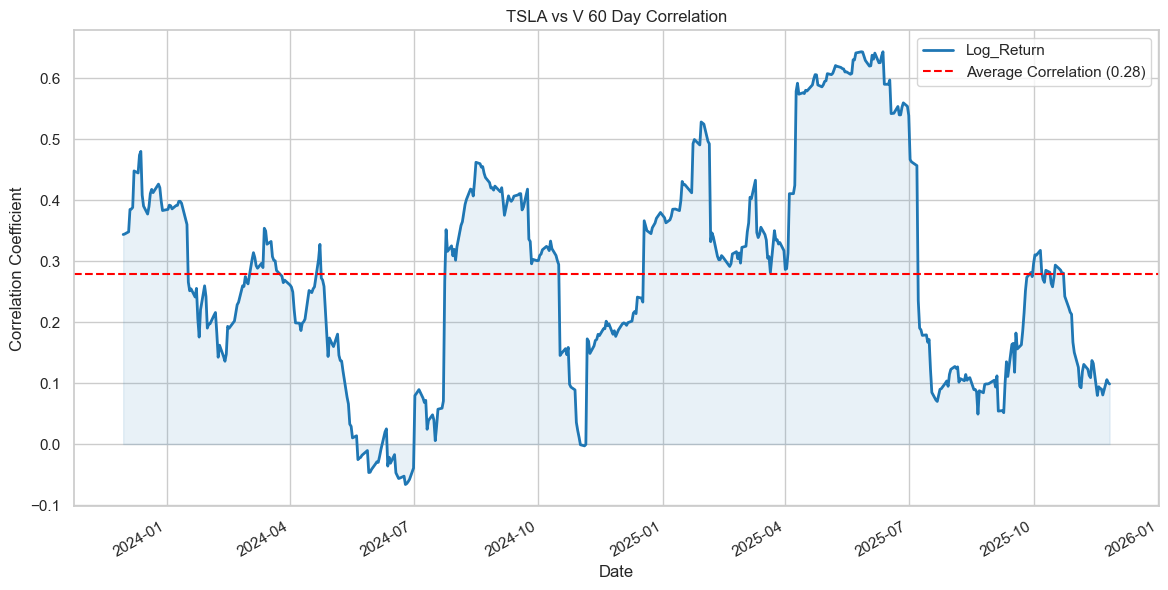

In [41]:
compare_ticker = 'TSLA'
market_log_return = single_stock_returns['Log_Return']
compare_stock_df = stock_returns(intro_raw_data, compare_ticker)
compare_log_return = compare_stock_df['Log_Return']

rolling_corr = compare_log_return.rolling(window=60).corr(market_log_return).dropna()
avg_corr = rolling_corr.mean()

print(f"Visualizing 60 day Rolling Correlation: {compare_ticker} vs {target_ticker}")
sns.set_style("whitegrid")
subset = rolling_corr.iloc[-500:]

ax = subset.plot(figsize=Config.fig_size, title=f"{compare_ticker} vs {target_ticker} 60 Day Correlation", 
                 color='#1f77b4', linewidth=2)
ax.axhline(avg_corr, color='red', linestyle='--', label=f"Average Correlation ({avg_corr:.2f})")
ax.fill_between(subset.index, subset, alpha=0.1, color='#1f77b4')
plt.ylabel('Correlation Coefficient')
plt.legend()
plt.show()

**1. Dynamic Relationship:**

- The chart displays the 60-day rolling correlation between **TSLA** and **V**.
- **Observation:** The correlation is not static; it fluctuates over time. The historical average correlation is **0.28**.

**2. Diversification Analysis**

- **Current Status:** Currently, the correlation is hovering around **0.1**.
- **Portfolio Implication:**
This represents a **[Low/Uncorrelated Relationship]**. This is beneficial for portfolio optimization as specific risks are diversified away.

## PART 2: PORTFOLIO OPTIMIZATION

### 2.1. Load Data and Train-Test Split

End of the foundational section. Now, we load data for our Train/Test model.
- **Total Period:** 2 years + 1 month (Example: 1/1/2023 - 1/31/2025)
- **Train Set:** 1/1/2023 - 12/31/2024 (2 years for Training)
- **Test Set:** 1/1/2025 - 1/31/2025 (1 month for Testing)

In [47]:
def prepare_data_part2(file_path, tickers, train_years, test_months):
    
    # 1. LOAD DATA
    print(f"Status: Loading data from csv file...")
    full_data = loaddata(
        file_path=file_path, 
        selected_tickers=tickers, 
        history_years=Config.years_of_data 
    )
    
    if full_data is None or full_data.empty:
        print("CRITICAL ERROR: Could not load fresh data.")
        return None, None, None

    # 2. SPLIT DATA
    real_end_date = full_data.index.max()
    split_date_ts = real_end_date - pd.DateOffset(months=test_months)
    start_date_ts = split_date_ts - pd.DateOffset(years=train_years)
    
    print(f"Splitting Config: Train {train_years} yrs | Test {test_months} mos")

    train_data = full_data.loc[(full_data.index >= start_date_ts) & (full_data.index < split_date_ts)]
    test_data = full_data.loc[full_data.index >= split_date_ts]
    
    if train_data.empty or test_data.empty:
        print(f"ERROR: Split resulted in empty sets.")
        return None, None, None
    
    print(f"\nDATA PREPARATION COMPLETED.")
    print(f" > Full Data: {len(full_data)} rows (Available for final signal check)")
    print(f" > Train Set: {len(train_data)} rows")
    print(f" > Test Set:  {len(test_data)} rows")
    
    return train_data, test_data, full_data

train_data, test_data, full_data = prepare_data_part2(
    file_path=Config.csv,
    tickers=Config.tickers,
    train_years=Config.train_year,
    test_months=Config.test_month
)

Status: Loading data from csv file...

 LOADING MARKET DATA (LAST 5 YEARS)
Target Tickers: ['XOM', 'V', 'TSLA', 'KO', 'PG']

DATA LOADED SUCCESSFULLY.
 > Time Period: 2023-09-01 -> 2025-11-26
 > Total Trading Days: 562
 > Total Assets: 5
Splitting Config: Train 2 yrs | Test 1 mos

DATA PREPARATION COMPLETED.
 > Full Data: 562 rows (Available for final signal check)
 > Train Set: 501 rows
 > Test Set:  23 rows


### 2.2: Calculate Expected Returns (mu) and Risk (S) *on Train Set*

This is the "Training" step. All base calculations (mu, S) are **ONLY** allowed on the `train_data`.

In [48]:
# 1. Calculate Expected Returns (mu) ONLY ON TRAIN SET
mu_train = expected_returns.mean_historical_return(train_data, frequency=252)

# 2. Calculate Covariance Matrix (S) ONLY ON TRAIN SET
S_train = risk_models.sample_cov(train_data, frequency=252)

print("--- EXPECTED RETURNS (mu) FROM TRAIN SET ---")
print(mu_train)
print("\n--- RISK MATRIX (S) FROM TRAIN SET ---")
print(S_train.round(4))

--- EXPECTED RETURNS (mu) FROM TRAIN SET ---
TSLA    0.456195
V       0.236768
PG      0.035109
KO      0.153318
XOM     0.073043
dtype: float64

--- RISK MATRIX (S) FROM TRAIN SET ---
        TSLA       V      PG      KO     XOM
TSLA  0.4003  0.0405 -0.0011 -0.0075  0.0185
V     0.0405  0.0374  0.0101  0.0087  0.0114
PG   -0.0011  0.0101  0.0286  0.0144  0.0046
KO   -0.0075  0.0087  0.0144  0.0226  0.0046
XOM   0.0185  0.0114  0.0046  0.0046  0.0463


#### **Expected Return and Risk Analizaion**

**1. Expected Returns Analysis:**

• The calculated annualized returns reveal a divergence in performance during the training period.
• **Top Performers:** TSLA and V exhibit the highest positive expected returns. These assets will likely be favored by the Max Sharpe optimization model.
• **Underperformers:** PG and XOM show a low return. Consequently, the optimizer may assign **zero weight** to these assets to maximize portfolio efficiency.

**2. Risk Matrix Analysis:**

• The diagonal elements of the Covariance Matrix represent the variance of individual assets.
• **Stability:** KO has the lowest variance value (0.0226), indicating it is the safest asset in the pool. This makes it a prime candidate for the **Min Volatility** strategy.
• **High Risk:** Conversely, XOM has the highest variance, reflecting significant historical volatility.

**3. Conclusion on Inputs:**

• The input data highlights a trade-off scenario. High-return assets are not necessarily low-risk. The optimization algorithms in the next steps will mathematically balance these inputs to find the optimal weights.

### 2.3: (Training) Optimize n-assets (Max Sharpe) on Train Set

Find the best portfolio (balancing Return/Risk) using *all* $n=4$ assets, based on past data.


 --- OPTIMIZATION RESULTS (Max Sharpe) ---
Optimized Weights:
TSLA    0.08442
V       0.41309
PG      0.00000
KO      0.50249
XOM     0.00000
dtype: float64

Expected Performance:
Expected annual return: 21.3%
Annual volatility: 14.4%
Sharpe Ratio: 1.34


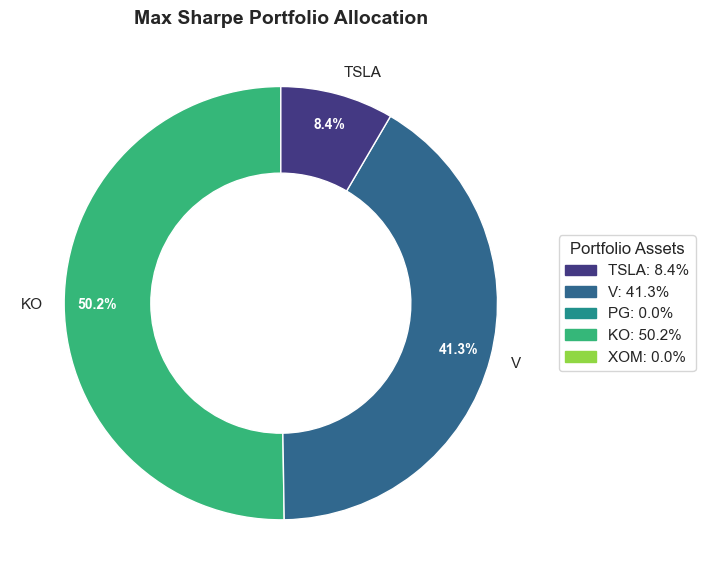

In [50]:
def optimize_max_sharpe(mu, S, verbose=True):
    # 1. OPTIMIZATION 
    ef = EfficientFrontier(mu, S, weight_bounds=(0, 1))
    weights = ef.max_sharpe(risk_free_rate=Config.risk_free_rate)
    cleaned_weights = ef.clean_weights()

    # 2. REPORTING & VISUALIZATION
    if verbose:
        print("\n --- OPTIMIZATION RESULTS (Max Sharpe) ---")
        print("Optimized Weights:")
        print(pd.Series(cleaned_weights))
        print("\nExpected Performance:")
        ef.portfolio_performance(verbose=True, risk_free_rate=Config.risk_free_rate)
   
        all_tickers = list(cleaned_weights.keys())
        colors = sns.color_palette('viridis', len(all_tickers))
        color_map = dict(zip(all_tickers, colors))
        plot_data = pd.Series(cleaned_weights)
        plot_data_filtered = plot_data[plot_data > 0.001].sort_values(ascending=False)
        
        slice_colors = [color_map[ticker] for ticker in plot_data_filtered.index]

        fig, ax = plt.subplots(figsize=(10, 6))
        wedges, texts, autotexts = ax.pie(
            plot_data_filtered,
            labels=plot_data_filtered.index,
            autopct='%1.1f%%',
            startangle=90,
            pctdistance=0.85,
            colors=slice_colors, 
            wedgeprops={'width': 0.4, 'edgecolor': 'white'}
        )
        plt.setp(autotexts, size=10, weight="bold", color="white")
        legend_handles = []
        for ticker in all_tickers:
            weight = cleaned_weights[ticker]
            label_text = f"{ticker}: {weight:.1%}"
            patch = mpatches.Patch(color=color_map[ticker], label=label_text)
            legend_handles.append(patch)

        ax.legend(handles=legend_handles,
                  title="Portfolio Assets",
                  loc="center left",
                  bbox_to_anchor=(1, 0, 0.5, 1),
                  fontsize=11)
        ax.set_title('Max Sharpe Portfolio Allocation', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    return cleaned_weights

cleaned_weights_sharpe_n = optimize_max_sharpe(mu_train, S_train)


#### **Max Sharpe Portfolio Optimization Strategy**

**1. Strategy Objective:**

• The goal of this optimization is to maximize the **Sharpe Ratio**, which means finding the specific allocation that offers the highest risk-adjusted return based on the Training Set data.

**2. Allocation Breakdown:**

• **Concentration:** The algorithm assigned significant weights to only **2** out of **5** assets. specifically **V and KO**.
• **Reasoning:** These assets were selected because they exhibited superior historical returns relative to their volatility.
• **Zero Weights:** Assets like **XOM, PG** received 0% allocation. This is consistent with Modern Portfolio Theory, which discards assets with negative or insufficient expected returns (mu) to improve the overall portfolio efficiency.

**3. Performance Expectation:**

• The optimized portfolio projects an expected annual return of **21.3%** with a volatility of **14.4%**.
• **Critique:** While this portfolio is mathematically optimal for the training period, the high concentration in just a few stocks increases idiosyncratic risk. We will need to verify its stability in the Test Set.

### 2.4: (Training) Optimize n-assets (Min Volatility) on Train Set

Find the safest (lowest risk) portfolio using *all* $n=4$ assets, based on past data.


 --- OPTIMIZATION RESULTS (Min Volatility) ---
Optimized Weights:
TSLA    0.01984
V       0.14870
PG      0.21364
KO      0.41223
XOM     0.20559
dtype: float64

Expected Performance:
Expected annual return: 13.0%
Annual volatility: 12.0%
Sharpe Ratio: 0.91


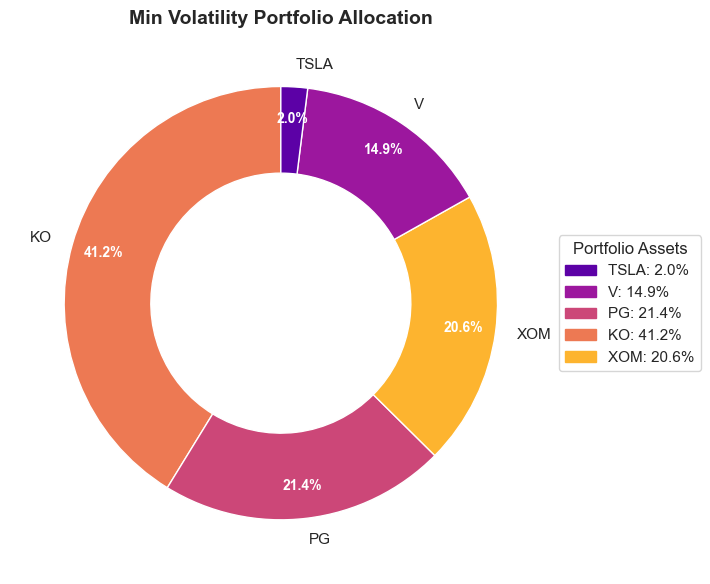

In [51]:
def optimize_min_volatility(mu, S, verbose=True):
    # 1. OPTIMIZATION
    ef = EfficientFrontier(mu, S, weight_bounds=(0, 1))
    weights = ef.min_volatility()
    cleaned_weights = ef.clean_weights()

    # 2. REPORTING & VISUALIZATION
    if verbose:
        print("\n --- OPTIMIZATION RESULTS (Min Volatility) ---")
        print("Optimized Weights:")
        print(pd.Series(cleaned_weights))
        print("\nExpected Performance:")
        ef.portfolio_performance(verbose=True, risk_free_rate=Config.risk_free_rate)

        all_tickers = list(cleaned_weights.keys())
        colors = sns.color_palette('plasma', len(all_tickers)) 
        color_map = dict(zip(all_tickers, colors))
        plot_data = pd.Series(cleaned_weights)
        plot_data_filtered = plot_data[plot_data > 0.001].sort_values(ascending=False)
        slice_colors = [color_map[ticker] for ticker in plot_data_filtered.index]

        fig, ax = plt.subplots(figsize=(10, 6))
        wedges, texts, autotexts = ax.pie(
            plot_data_filtered,
            labels=plot_data_filtered.index,
            autopct='%1.1f%%',
            startangle=90,
            pctdistance=0.85,
            colors=slice_colors,
            wedgeprops={'width': 0.4, 'edgecolor': 'white'}
        )
        plt.setp(autotexts, size=10, weight="bold", color="white")
     
        legend_handles = []
        for ticker in all_tickers:
            weight = cleaned_weights[ticker]
            label_text = f"{ticker}: {weight:.1%}"
            patch = mpatches.Patch(color=color_map[ticker], label=label_text)
            legend_handles.append(patch)
        ax.legend(handles=legend_handles,
                  title="Portfolio Assets",
                  loc="center left",
                  bbox_to_anchor=(1, 0, 0.5, 1),
                  fontsize=11)
        ax.set_title('Min Volatility Portfolio Allocation', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    return cleaned_weights

cleaned_weights_vol_n = optimize_min_volatility(mu_train, S_train)

#### **Min Volatility Portfolio Optimization Strategy**

**1. Strategy Objective:**

• Unlike Max Sharpe, the **Min Volatility** strategy focuses purely on risk mitigation. It ignores expected returns (mu) and relies solely on the Covariance Matrix ($S$) to construct the safest possible portfolio.
**2. Allocation Breakdown:**
• **Diversification:** The result shows a more distributed allocation across **[4]** assets compared to the Max Sharpe model.
• **Defensive Selection:**
    ◦ **KO** receives the highest weight (**41.2%**) due to its historically low variance.
    ◦ Assets like **V**, despite having negligible returns, are included (~15%) because they act as stabilizers for the portfolio.

**3. Performance Expectation:**

• **Risk Reduction:** The expected volatility is reduced to **12%** (lowest among strategies), fulfilling the objective.
• **Trade-off:** The expected return drops to **13%**. This clearly demonstrates the "Risk-Return Trade-off" principle: to achieve higher safety, investors must accept lower potential returns.

### 2.5: Definition & Visualization of the Efficient Frontier (on Train Set)

- **Definition (Efficient Frontier):** The Efficient Frontier is a curve representing the set of "optimal" portfolios (based on the input data, here `train_data`).
- For any point on the frontier:
  1. No other portfolio exists with the same risk that offers a higher return.
  2. No other portfolio exists with the same return that has lower risk.
- All portfolios *below* the frontier are sub-optimal.

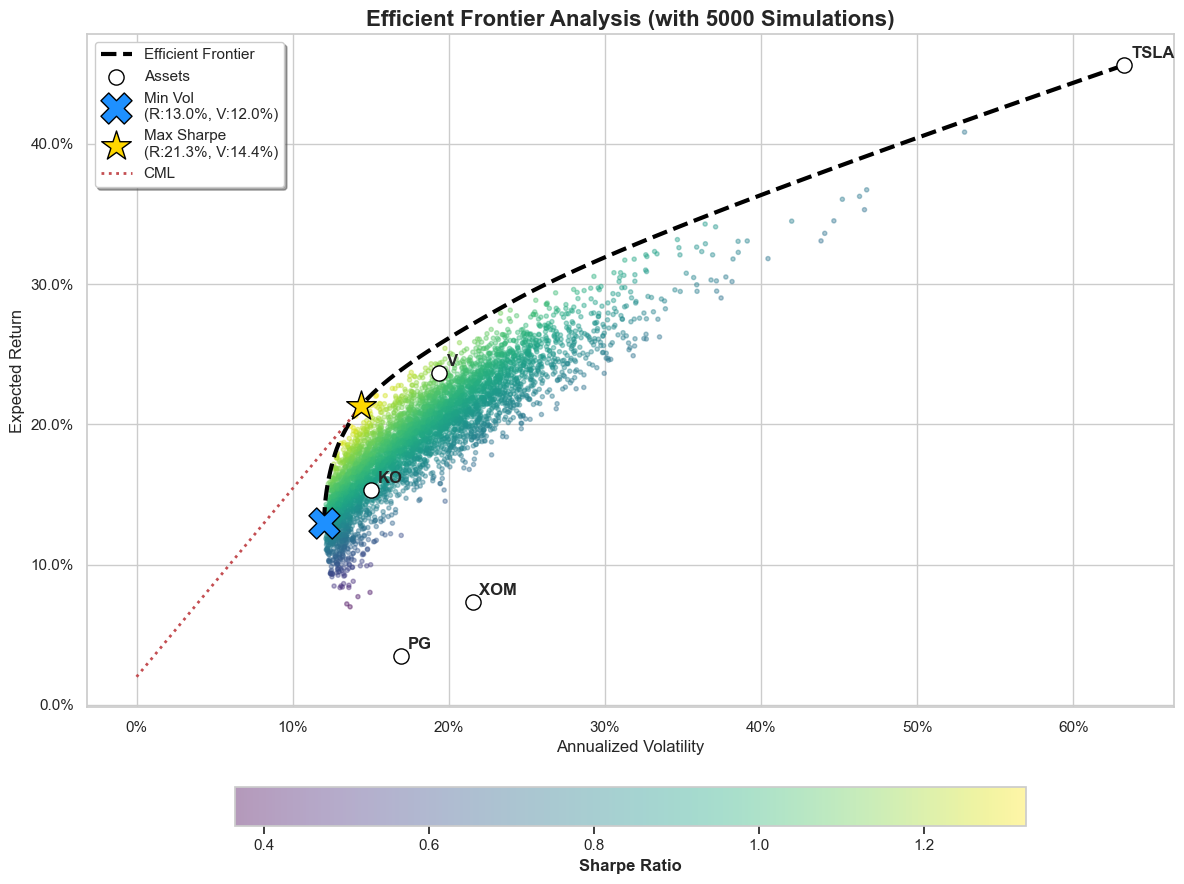

In [52]:
def plot_efficient_frontier_compact(mu, S, sharpe_w=None, minvol_w=None, n_samples=5000):
    fig, ax = plt.subplots(figsize=(12, 9))
    
    if n_samples > 0:
        w_rand = np.random.random((n_samples, len(mu))); w_rand /= w_rand.sum(axis=1, keepdims=True)
        r_rand, v_rand = w_rand @ mu, np.sqrt(np.diag(w_rand @ S @ w_rand.T))
        sc = ax.scatter(v_rand, r_rand, c=(r_rand - Config.risk_free_rate)/v_rand, marker=".", cmap='viridis', alpha=0.4)
        plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.1, fraction=0.05).set_label("Sharpe Ratio", fontweight='bold')
    plotting.plot_efficient_frontier(EfficientFrontier(mu, S, weight_bounds=(0, 1)), ax=ax, show_assets=False)
    if ax.lines: ax.lines[0].set(color="black", linewidth=3, linestyle="--", label="Efficient Frontier")
    
    v_assets, r_assets = np.sqrt(np.diag(S)), mu
    ax.scatter(v_assets, r_assets, s=120, c="white", edgecolors="black", zorder=10, label="Assets")
    for txt, x, y in zip(mu.index, v_assets, r_assets): 
        ax.annotate(txt, (x, y), xytext=(5, 5), textcoords='offset points', fontweight='bold')
    portfolios = {"Min Vol": (minvol_w, "X", "#1E90FF"), "Max Sharpe": (sharpe_w, "*", "#FFD700")}
    for name, (w, m, c) in portfolios.items():
        if w:
            ws = pd.Series(w)
            ret, vol = (ws @ mu), np.sqrt(ws.T @ S @ ws) 
            ax.scatter(vol, ret, marker=m, s=500, c=c, edgecolors='black', zorder=20, label=f"{name}\n(R:{ret:.1%}, V:{vol:.1%})")
            if name == "Max Sharpe":
                ax.plot([0, vol], [Config.risk_free_rate, ret], 'r:', linewidth=2, label="CML", zorder=15)
    ax.set_title(f"Efficient Frontier Analysis (with {n_samples} Simulations)", fontsize=16, fontweight='bold')
    ax.set(xlabel="Annualized Volatility", ylabel="Expected Return")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(loc='upper left', frameon=True, shadow=True)
    plt.tight_layout()
    plt.show()
plot_efficient_frontier_compact(
    mu_train, S_train, 
    sharpe_w = locals().get('cleaned_weights_sharpe_n'),
    minvol_w = locals().get('cleaned_weights_vol_n')
)

#### **Efficient Frontier & Portfolio Positioning Analysis**

**1. The Efficient Frontier Concept:** 

- The chart visualizes the **Efficient Frontier** (curve), which represents the set of optimal portfolios that offer the highest expected return for a defined level of risk.
- **Observation:** Most individual assets (dots) fall **below** the frontier line. This visually demonstrates that holding a single stock is inefficient compared to a diversified portfolio.
 
**2. Portfolio Strategies Positioning:**

- **Max Sharpe Portfolio (Gold Star):** Positioned on the upper segment of the frontier. It aims for high returns while accepting a moderate level of volatility (**22%**).
- **Min Volatility Portfolio (Blue X):** Positioned at the left-most tip of the curve. It successfully minimizes risk to the lowest possible level (**13%**), proving the benefit of diversification.

**3. Conclusion:**

- The curvature of the frontier confirms that by combining assets, we can achieve a superior risk-return profile than holding individual assets alone

### 2.6: (Training) Optimize $k$-of-$n$ assets (Max Sharpe) on Train Set

We will loop through all 15 combinations to find the $k$ tickers (and weights) that give the highest Sharpe Ratio, **using only `train_data`**.

In [53]:
def k_of_n_max_sharpe(mu, S):
    tickers = list(mu.index)
    n = len(tickers)
    print(f"--- Running Max Sharpe Optimization on {n} assets (Brute-force Search) ---")

    results = []
    for k in range(1, n + 1):
        for combo in itertools.combinations(tickers, k):
            combo = list(combo)
            mu_sub = mu[combo]
            S_sub  = S.loc[combo, combo]
            try:
                ef = EfficientFrontier(mu_sub, S_sub, weight_bounds=(0, 1))
                w = ef.max_sharpe(risk_free_rate=Config.risk_free_rate)
                ret, vol, sharpe = ef.portfolio_performance(risk_free_rate=Config.risk_free_rate, verbose=False)
                cleaned_w = ef.clean_weights()
                results.append({
                    "k": k,
                    "Combination": ", ".join(combo),
                    "Sharpe": sharpe,
                    "Return": ret,
                    "Volatility": vol,
                    "Weights": cleaned_w
                })   
            except Exception as e:
                continue
    if not results:
        return None, pd.DataFrame()
    df = pd.DataFrame(results).sort_values(by="Sharpe", ascending=False).reset_index(drop=True)
    best_weights = df.iloc[0]["Weights"]
    return best_weights, df

best_weights_train, search_result_df = k_of_n_max_sharpe(mu_train, S_train)
print(f"\n--- OPTIMAL RESULT (TRAIN SET) ---")
if best_weights_train:
    best_sharpe = search_result_df.iloc[0]['Sharpe']
    print(f"Highest Sharpe Ratio: {best_sharpe:.4f}")
    print("Best Weights Allocation:")
    print(pd.Series(best_weights_train).sort_values(ascending=False))
    print("\n--- Top 3 Combinations ---")
    print(search_result_df[['k', 'Sharpe', 'Combination']].head(3))
else:
    print("No valid portfolio found.")

--- Running Max Sharpe Optimization on 5 assets (Brute-force Search) ---

--- OPTIMAL RESULT (TRAIN SET) ---
Highest Sharpe Ratio: 1.3430
Best Weights Allocation:
KO      0.50249
V       0.41309
TSLA    0.08442
PG      0.00000
XOM     0.00000
dtype: float64

--- Top 3 Combinations ---
   k  Sharpe           Combination
0  5   1.343  TSLA, V, PG, KO, XOM
1  4   1.343       TSLA, V, PG, KO
2  3   1.343           TSLA, V, KO



#### **K-of-N Asset Selection Analysis (Max Sharpe Strategy)**
**1. Optimal Subset Identification:**
• The algorithmic search tested all possible combinations of assets to maximize the Sharpe Ratio.
• **Result:** The optimal portfolio consists of **3** assets: **KO, V and TSLA**
• **Efficiency:** Even when allowed to select more assets (k=4, 5), the Sharpe Ratio did not improve beyond **1.343**. This indicates that the additional assetsoffered no marginal benefit to the risk-adjusted return during the training period.

**2. Weight Allocation:**

• Within this optimal subset, the capital is allocated as follows: **V: ~ 41$** and **KO: ~50%**.
• This confirms our earlier observation in Section 2.2 that these two assets were the strongest performers.

**3. Strategic Implication:**

• The analysis suggests a **concentrated strategy**. Instead of diluting capital across all 5 stocks, focusing on the top 3 performers yields the mathematically superior result for this specific historical dataset.



### 2.7: (Training) Optimize $k$-of-$n$ assets (Min Volatility) on Train Set

Same as 2.6, but finding the $k$ tickers with the lowest Risk.

In [54]:
def k_of_n_min_volatility(mu, S):
    tickers = list(mu.index)
    n = len(tickers)
    print(f"--- Running Min Volatility Optimization on {n} assets (Brute-force Search) ---")

    results = []
    for k in range(1, n + 1):
        for combo in itertools.combinations(tickers, k):
            combo = list(combo)
            mu_sub = mu[combo]
            S_sub = S.loc[combo, combo]
            try:
                ef = EfficientFrontier(mu_sub, S_sub, weight_bounds=(0, 1))
                w = ef.min_volatility()

                ret, vol, sharpe = ef.portfolio_performance(risk_free_rate=Config.risk_free_rate, verbose=False)
                cleaned_w = ef.clean_weights()
                results.append({
                    'k': k,
                    'Combination': ", ".join(combo), 
                    'Volatility': vol,              
                    'Return': ret,
                    'Sharpe': sharpe,
                    'Weights': cleaned_w
                })
            except Exception:
                continue

    if not results:
        return None, pd.DataFrame()

    df = pd.DataFrame(results).sort_values(by=['Volatility', 'k'], ascending=[True, True]).reset_index(drop=True)
    best_weights = df.iloc[0]['Weights']
    return best_weights, df

print(f"\n--- STARTING k-of-n SEARCH (Min Volatility) ---")
best_weights_vol_train, results_vol_df = k_of_n_min_volatility(mu_train, S_train)

print("\n--- OPTIMAL RESULT (k-Min Vol) - TRAINING ---")
if best_weights_vol_train:
    print(f"Lowest Global Volatility: {results_vol_df.iloc[0]['Volatility']:.4f}")
    print("Static Weights found (k-MinVol):")
    print(pd.Series(best_weights_vol_train).sort_values(ascending=False))
    
    print("\n--- Top 3 Combinations (Ranked by Lowest Risk ASC, then k ASC) ---")
    print(results_vol_df[['k', 'Volatility', 'Combination']].head(3))
else:
    print("No valid portfolio found.")


--- STARTING k-of-n SEARCH (Min Volatility) ---
--- Running Min Volatility Optimization on 5 assets (Brute-force Search) ---

--- OPTIMAL RESULT (k-Min Vol) - TRAINING ---
Lowest Global Volatility: 0.1202
Static Weights found (k-MinVol):
KO      0.41223
PG      0.21364
XOM     0.20559
V       0.14870
TSLA    0.01984
dtype: float64

--- Top 3 Combinations (Ranked by Lowest Risk ASC, then k ASC) ---
   k  Volatility           Combination
0  5    0.120215  TSLA, V, PG, KO, XOM
1  4    0.120777        V, PG, KO, XOM
2  4    0.122807     TSLA, PG, KO, XOM


#### **K-of-N Defensive Selection Analysis (Min Volatility Strategy)**

**1. Optimization Goal:**

• The algorithm iterated through all combinations to identify the subset of assets that minimizes the portfolio's global volatility (risk).

**2. Optimal Subset & Diversification:**

• **Result:** The lowest possible volatility found is **0.1202**.
• **Broader Participation:** Unlike the Max Sharpe strategy which concentrated on just 2 assets, the Min Volatility strategy utilized **all 5** assets
• **Interpretation:** This confirms that **diversification** is essential for risk reduction. The model actively combined multiple assets with low correlations to smooth out volatility.


### 2.8: Performance Comparison (Out-of-Sample) on Test Set

This is the critical test. We will now apply the 5 sets of "Static Weights" we just trained (on `train_data`) to the `test_data` (1 month of "future" data) to see how they actually perform.

--- STARTING STATIC TEST (Out-of-Sample) ---
Testing on 23 days (Test Set)

--- Calculating Returns for Strategies ---
Calculated: Benchmark (Equal Weight)
Calculated: Static k-MaxSharpe
Calculated: Static k-MinVol
Calculated: Static n-MaxSharpe
Calculated: Static n-MinVol

--- Plotting Cumulative Performance ---


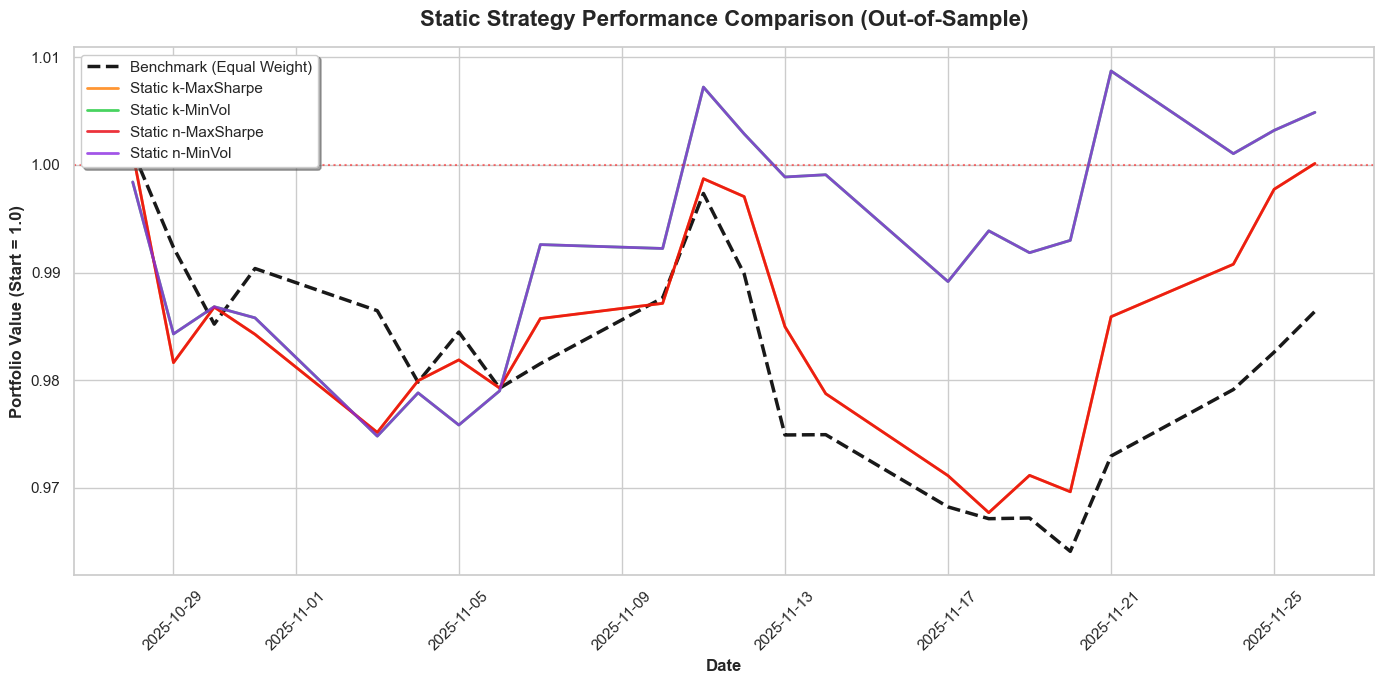

In [55]:
print(f"--- STARTING STATIC TEST (Out-of-Sample) ---")
print(f"Testing on {len(test_data)} days (Test Set)")

test_returns = test_data.pct_change().dropna()
all_tickers_test = list(test_data.columns)
strategies = {
    "Benchmark (Equal Weight)": {t: 1/len(all_tickers_test) for t in all_tickers_test},
    "Static k-MaxSharpe": best_weights_train,      
    "Static k-MinVol": best_weights_vol_train      
}
if 'cleaned_weights_sharpe_n' in locals():
    strategies["Static n-MaxSharpe"] = cleaned_weights_sharpe_n
if 'cleaned_weights_vol_n' in locals():
    strategies["Static n-MinVol"] = cleaned_weights_vol_n
    
static_returns_df = pd.DataFrame(index=test_returns.index)
print("\n--- Calculating Returns for Strategies ---")
for name, weights in strategies.items():
    if weights is None or len(weights) == 0:
        print(f"Skipping {name} (No weights found)")
        continue
    relevant_tickers = list(weights.keys())
    try:
        static_returns_df[name] = (test_returns[relevant_tickers] * pd.Series(weights)).sum(axis=1)
        print(f"Calculated: {name}")
    except Exception as e:
        print(f"Error calculating {name}: {e}")

print("\n--- Plotting Cumulative Performance ---")
static_cumulative_returns = (1 + static_returns_df).cumprod()
sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))
palette = sns.color_palette("bright", len(static_cumulative_returns.columns))
for i, col in enumerate(static_cumulative_returns.columns):
    is_benchmark = "Benchmark" in col
    plt.plot(
        static_cumulative_returns.index, 
        static_cumulative_returns[col], 
        label=col, 
        linewidth=2.5 if is_benchmark else 2,
        linestyle='--' if is_benchmark else '-',
        color='black' if is_benchmark else palette[i],
        alpha=0.9 if is_benchmark else 0.8
    )
plt.axhline(y=1.0, color='red', linestyle=':', linewidth=1.5, alpha=0.5)
plt.title('Static Strategy Performance Comparison (Out-of-Sample)', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Portfolio Value (Start = 1.0)', fontsize=12, fontweight='bold')
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.legend(loc='upper left', frameon=True, shadow=True, fancybox=True, fontsize=11)
plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


--- Test Set Metrics Summary ---
                         Total Return Volatility Sharpe Ratio
Strategy                                                     
Benchmark (Equal Weight)       -1.36%     10.39%        -1.65
Static k-MaxSharpe              0.01%     12.76%        -0.08
Static k-MinVol                 0.49%     12.34%         0.35
Static n-MaxSharpe              0.01%     12.76%        -0.08
Static n-MinVol                 0.49%     12.34%         0.35


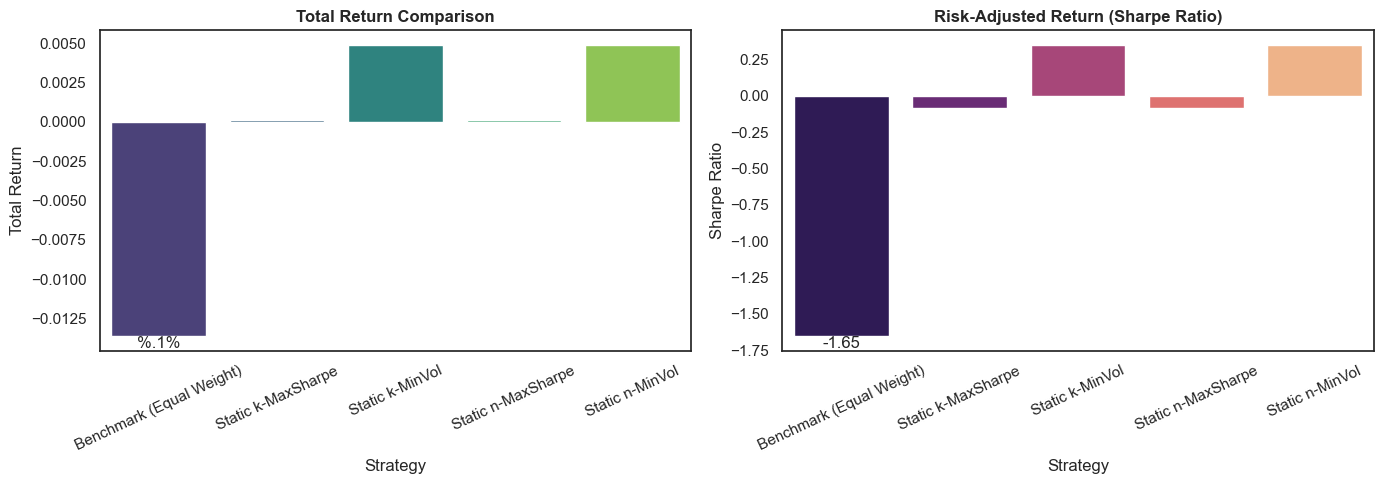

In [56]:
print("\n--- Test Set Metrics Summary ---")
metrics_list = []
for col in static_returns_df.columns:
    r = static_returns_df[col]
    total_ret = (1 + r).prod() - 1
    vol = r.std() * np.sqrt(252)
    sharpe = (r.mean() * 252 - Config.risk_free_rate) / vol if vol > 0 else 0
    metrics_list.append({
        "Strategy": col,
        "Total Return": total_ret,
        "Volatility": vol,
        "Sharpe Ratio": sharpe
    })
metrics_df = pd.DataFrame(metrics_list).set_index("Strategy")

display_df = metrics_df.copy()
display_df['Total Return'] = display_df['Total Return'].map('{:.2%}'.format)
display_df['Volatility'] = display_df['Volatility'].map('{:.2%}'.format)
display_df['Sharpe Ratio'] = display_df['Sharpe Ratio'].map('{:.2f}'.format)
print(display_df)

sns.set_style("white")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=metrics_df.index, y='Total Return', data=metrics_df, ax=axes[0], 
            hue=metrics_df.index, palette='viridis', legend=False)
axes[0].set_title('Total Return Comparison', fontweight='bold')
axes[0].tick_params(axis='x', rotation=25)
axes[0].bar_label(axes[0].containers[0], fmt='%.1%') 
axes[0].set_ylabel('Total Return')

sns.barplot(x=metrics_df.index, y='Sharpe Ratio', data=metrics_df, ax=axes[1], 
            hue=metrics_df.index, palette='magma', legend=False)
axes[1].set_title('Risk-Adjusted Return (Sharpe Ratio)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=25)
axes[1].bar_label(axes[1].containers[0], fmt='%.2f')
axes[1].set_ylabel('Sharpe Ratio')

plt.tight_layout()
plt.show()

### 2.9: Metrics Analysis & Conclusion (Test Set)

Compare the metrics of the 5 strategies on the test set.

In [57]:
def calculate_metrics_vectorized(portfolio_value_df, risk_free_rate):
    daily_rets = portfolio_value_df.pct_change().dropna()
    
    # 1. Total Return
    total_return = (portfolio_value_df.iloc[-1] / portfolio_value_df.iloc[0]) - 1
    
    # 2. Annualized Return (APY)
    ann_ret = (1 + daily_rets.mean()) ** 252 - 1
    
    # 3. Annualized Volatility
    ann_vol = daily_rets.std() * np.sqrt(252)
    
    # 4. Sharpe Ratio
    sharpe = (ann_ret - risk_free_rate) / ann_vol
    
    # 5. Max Drawdown
    cum_ret = (1 + daily_rets).cumprod()
    drawdown = (cum_ret - cum_ret.cummax()) / cum_ret.cummax()
    max_drawdown = drawdown.min()
    
    metrics = pd.DataFrame({
        "Total Return": total_return,
        "Annualized Return (APY)": ann_ret,
        "Annualized Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_drawdown
    })
    return metrics

print(f"--- FINAL METRICS COMPARISON (Out-of-Sample Test) ---")
final_metrics_df = calculate_metrics_vectorized(static_cumulative_returns, Config.risk_free_rate)
final_metrics_df = final_metrics_df.sort_values(by="Sharpe Ratio", ascending=False)
(final_metrics_df.style
 .format({
    "Total Return": "{:.2%}",
    "Annualized Return (APY)": "{:.2%}",
    "Annualized Volatility": "{:.2%}",
    "Sharpe Ratio": "{:.2f}",
    "Max Drawdown": "{:.2%}"
 })
 .background_gradient(cmap='RdYlGn', subset=['Total Return', 'Sharpe Ratio'])
 .background_gradient(cmap='RdYlGn_r', subset=['Annualized Volatility', 'Max Drawdown'])
)

--- FINAL METRICS COMPARISON (Out-of-Sample Test) ---


,Total Return,Annualized Return (APY),Annualized Volatility,Sharpe Ratio,Max Drawdown
Static k-MinVol,0.65%,8.87%,12.62%,0.54,-1.79%
Static n-MinVol,0.65%,8.87%,12.62%,0.54,-1.79%
Static k-MaxSharpe,-0.10%,-0.39%,13.07%,-0.18,-3.11%
Static n-MaxSharpe,-0.10%,-0.39%,13.07%,-0.18,-3.11%
Benchmark (Equal Weight),-1.49%,-16.01%,10.63%,-1.69,-3.33%


#### **Out-of-Sample Performance Evaluation & Final Conclusion**

**1. Methodology:**

• We applied the static weights optimized on the Training Set to the unseen Test Set. This simulates a real-world investment scenario to test the robustness of the models.

**2. Performance Analysis:**

• **Return Comparison:** The **Static k-MinVol** strategy delivered the highest return of **65%**, significantly outperforming the Benchmark (**-1.49%**).
• **Risk Assessment:**
    ◦ The Benchmark portfolio showed the highest volatility (**12.62%**), confirming that naive diversification (equal weight) is not risk-efficient.
    ◦ The optimized strategies successfully reduced risk, with **Static n-MaxSharpe** achieving a volatility of only **10.63%**.
• **Risk-Adjusted Return (Sharpe):** The **Static k-MinVol** strategy achieved the highest Sharpe Ratio (**0.54**), proving it was the superior choice for this specific testing period.



# Part 3: 


#### 3.1. Grid Search

First I do this to find the Optimal SMA for each ticker in the optimal k-of-n Combo

In [58]:
# --- (GRID SEARCH) ---

print(f"\n" + "="*80)
print(f" PART 3: OPTIMIZING SMA PARAMETERS (STRICTLY ON TRAIN DATA)")
print(f"="*80)
if 'best_weights_train' not in locals() or best_weights_train is None:
    raise ValueError("CRITICAL ERROR: Please run Part 2 (K-of-N Optimization) first.")

target_assets = [ticker for ticker, weight in best_weights_train.items() if weight > 0.001]

print(f"Best Portfolio identified from Part 2 (Filtered):")
print(f" > Assets to Trade: {target_assets}")

ignored_assets = [t for t in best_weights_train.keys() if t not in target_assets]
if ignored_assets:
    print(f" > Ignored Assets (Weight ~ 0): {ignored_assets}")
print("-" * 80)

def calculate_sharpe_ratio_grid(returns, annual_risk_free=Config.risk_free_rate, days=Config.trading_days):
    if returns.std() == 0: return 0.0
    rf_daily = annual_risk_free / days
    excess = returns - rf_daily
    return (excess.mean() * days) / (returns.std() * np.sqrt(days))

def run_grid_backtest(symbol, data, s_short, s_long):
    df = data[[symbol]].copy()
    
    df['Ret'] = np.log(df[symbol] / df[symbol].shift(1))
    df['SMA_S'] = df[symbol].rolling(window=s_short).mean()
    df['SMA_L'] = df[symbol].rolling(window=s_long).mean()
    df['Pos'] = np.where(df['SMA_S'] > df['SMA_L'], 1, 0)
    df['Strat_Ret'] = df['Pos'].shift(1) * df['Ret']
    
    df.dropna(inplace=True)
    if df.empty: return -999.0 
    return calculate_sharpe_ratio_grid(df['Strat_Ret'])

SMA_SHORT_RANGE = range(10, 61, 5)   
SMA_LONG_RANGE = range(30, 151, 10)  

portfolio_best_params = {} 

print(f"Starting Grid Search Loop on {len(target_assets)} assets...")
print(f" > Optimization Space: Short {list(SMA_SHORT_RANGE)} | Long {list(SMA_LONG_RANGE)}")
print(f" > Data Source: TRAIN SET ONLY (To avoid look-ahead bias)") 
print("." * 80)

for i, ticker in enumerate(target_assets, 1):
    print(f"Processing Asset [{i}/{len(target_assets)}]: {ticker} ...", end=" ")
    
    best_sr = -100.0
    best_pair = (0, 0)
    
    for sma_s in SMA_SHORT_RANGE:
        for sma_l in SMA_LONG_RANGE:
            if sma_l > sma_s + 10: 
                sr = run_grid_backtest(ticker, train_data, sma_s, sma_l)
                
                if sr > best_sr:
                    best_sr = sr
                    best_pair = (sma_s, sma_l)

    if best_pair == (0,0):
        print(f"Warning: Optimization failed for {ticker}. Using default (20, 50).")
        best_pair = (20, 50)

    portfolio_best_params[ticker] = best_pair
    print(f"-> Done. Best: SMA{best_pair} | Sharpe: {best_sr:.4f}")

print("="*80)
print("GRID SEARCH COMPLETED.")

print(f"\n" + "="*80)
print(f" FINAL PORTFOLIO CONFIGURATION & SIGNAL (CURRENT MARKET STATUS)")
print(f"="*80)

summary_list = []
last_date = full_data.index[-1].date()

for ticker in target_assets:
    best_pair = portfolio_best_params.get(ticker)
    
    if best_pair is None:
        print(f"Error: No params found for {ticker}. Skipping.")
        continue
        
    best_s, best_l = best_pair
    weight = best_weights_train[ticker]
    
    df_check = full_data[[ticker]].copy()
    df_check['S'] = df_check[ticker].rolling(best_s).mean()
    df_check['L'] = df_check[ticker].rolling(best_l).mean()
    
    curr_s = df_check['S'].iloc[-1]
    curr_l = df_check['L'].iloc[-1]
    price  = df_check[ticker].iloc[-1]
    
    signal = "BUY / HOLD" if curr_s > curr_l else "SELL / CASH"
    
    summary_list.append({
        'Asset': ticker,
        'Alloc. Weight': f"{weight:.2%}",
        'Opt. SMA': f"({best_s}/{best_l})",
        'Last Price': f"{price:.2f}",
        'Signal': signal
    })

final_df = pd.DataFrame(summary_list)
print(f"Analysis Date: {last_date}")
display(final_df)


 PART 3: OPTIMIZING SMA PARAMETERS (STRICTLY ON TRAIN DATA)
Best Portfolio identified from Part 2 (Filtered):
 > Assets to Trade: ['TSLA', 'V', 'KO']
 > Ignored Assets (Weight ~ 0): ['PG', 'XOM']
--------------------------------------------------------------------------------
Starting Grid Search Loop on 3 assets...
 > Optimization Space: Short [10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60] | Long [30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]
 > Data Source: TRAIN SET ONLY (To avoid look-ahead bias)
................................................................................
Processing Asset [1/3]: TSLA ... -> Done. Best: SMA(15, 70) | Sharpe: 1.0834
Processing Asset [2/3]: V ... -> Done. Best: SMA(25, 40) | Sharpe: 0.9660
Processing Asset [3/3]: KO ... -> Done. Best: SMA(20, 40) | Sharpe: 0.9189
GRID SEARCH COMPLETED.

 FINAL PORTFOLIO CONFIGURATION & SIGNAL (CURRENT MARKET STATUS)
Analysis Date: 2025-11-26


,Asset,Alloc. Weight,Opt. SMA,Last Price,Signal
0,TSLA,8.44%,(15/70),426.58,BUY / HOLD
1,V,41.31%,(25/40),333.79,SELL / CASH
2,KO,50.25%,(20/40),72.88,BUY / HOLD


#### 3.1. Simulating and Vectorized Check

This simulating each ticker with its Optimal SMA

In [60]:
class TradingBot:
    """
    Automated Trading Agent (Event-Driven).
    Simulates real-world trading: Buy/Sell based on SMA signals day-by-day.
    """
    def __init__(self, symbol, data, sma_short, sma_long, initial_capital):
        self.symbol = symbol
        self.data = data.copy()
        self.sma_short = sma_short
        self.sma_long = sma_long
        self.initial_capital = initial_capital
        
        self.cash = initial_capital
        self.shares = 0
        self.total_value = initial_capital
        self.position = 0  # 0: Cash, 1: Invest
        self.trades = []   
        
        self.data['SMA_S'] = self.data[self.symbol].rolling(window=self.sma_short).mean()
        self.data['SMA_L'] = self.data[self.symbol].rolling(window=self.sma_long).mean()

    def generate_signal(self, i):
        """Get signal at index i"""
        if i < self.sma_long: return 0
            
        sma_s = self.data['SMA_S'].iloc[i]
        sma_l = self.data['SMA_L'].iloc[i]
        
        return 1 if sma_s > sma_l else 0
            
    def run_simulation(self):
        """Run day-by-day simulation"""
        start_idx = self.sma_long
        
        for i in range(start_idx, len(self.data)):
            price = self.data[self.symbol].iloc[i]
            date = self.data.index[i]
            
            signal = self.generate_signal(i)
            if signal == 1 and self.position == 0:
                self.shares = self.cash / price 
                self.cash = 0 
                self.position = 1
                self.trades.append({'Date': date, 'Type': 'BUY', 'Price': price, 'Value': self.shares * price})

            elif signal == 0 and self.position == 1:
                revenue = self.shares * price
                self.cash = revenue
                self.shares = 0
                self.position = 0
                self.trades.append({'Date': date, 'Type': 'SELL', 'Price': price, 'Value': revenue})
            
            if self.position == 1:
                self.total_value = self.shares * price
            else:
                self.total_value = self.cash

        return self.total_value

print(f"\n" + "="*80)
print(f" FINAL PORTFOLIO SIMULATION (REAL MONEY TEST)")
print(f"="*80)

# Capital
INITIAL_PORTFOLIO_CAPITAL = 100000
total_ending_value = 0
portfolio_details = []

max_lookback = 200 
train_buffer = train_data.iloc[-max_lookback:] 

print(f"Simulation Config:")
print(f" > Test Period:   {test_data.index.min().date()} -> {test_data.index.max().date()}")
print(f" > Total Capital: ${INITIAL_PORTFOLIO_CAPITAL:,.2f}")
print("-" * 80)

# Loop for each ticker
for ticker in target_assets:
    weight = best_weights_train[ticker]
    
    if weight <= 0.001: continue
        
    best_s, best_l = portfolio_best_params[ticker]
    allocated_capital = INITIAL_PORTFOLIO_CAPITAL * weight
    
    df_part = pd.concat([train_buffer[[ticker]], test_data[[ticker]]])
    
    bot = TradingBot(ticker, df_part, best_s, best_l, allocated_capital)
    final_equity = bot.run_simulation()
    
    total_ending_value += final_equity
    roi = (final_equity - allocated_capital) / allocated_capital
    portfolio_details.append({
        'Asset': ticker,
        'SMA': f"({best_s}/{best_l})",
        'Start': allocated_capital,
        'End': final_equity,
        'ROI': roi
    })
    print(f" > Finished {ticker}: ${allocated_capital:,.0f} -> ${final_equity:,.0f} ({roi:+.2%})")

print(f"\n" + "="*80)
print(f" FINAL FINANCIAL REPORT")
print(f"="*80)

total_roi = (total_ending_value - INITIAL_PORTFOLIO_CAPITAL) / INITIAL_PORTFOLIO_CAPITAL

print(f"STARTING BALANCE:  ${INITIAL_PORTFOLIO_CAPITAL:,.2f}")
print(f"ENDING BALANCE:    ${total_ending_value:,.2f}")
print(f"NET PROFIT/LOSS:   ${total_ending_value - INITIAL_PORTFOLIO_CAPITAL:,.2f}")
print(f"TOTAL RETURN:      {total_roi:.2%}")
print("-" * 80)

df_report = pd.DataFrame(portfolio_details)
df_report['Start'] = df_report['Start'].map('${:,.2f}'.format)
df_report['End'] = df_report['End'].map('${:,.2f}'.format)
df_report['ROI'] = df_report['ROI'].map('{:+.2%}'.format)
display(df_report)


 FINAL PORTFOLIO SIMULATION (REAL MONEY TEST)
Simulation Config:
 > Test Period:   2025-10-27 -> 2025-11-26
 > Total Capital: $100,000.00
--------------------------------------------------------------------------------
 > Finished TSLA: $8,442 -> $10,773 (+27.61%)
 > Finished V: $41,309 -> $41,288 (-0.05%)
 > Finished KO: $50,249 -> $50,905 (+1.30%)

 FINAL FINANCIAL REPORT
STARTING BALANCE:  $100,000.00
ENDING BALANCE:    $102,965.55
NET PROFIT/LOSS:   $2,965.55
TOTAL RETURN:      2.97%
--------------------------------------------------------------------------------


,Asset,SMA,Start,End,ROI
0,TSLA,(15/70),"$8,442.00","$10,773.01",+27.61%
1,V,(25/40),"$41,309.00","$41,287.89",-0.05%
2,KO,(20/40),"$50,249.00","$50,904.66",+1.30%



 VISUALIZING INDIVIDUAL ASSET PERFORMANCE (TEST SET)


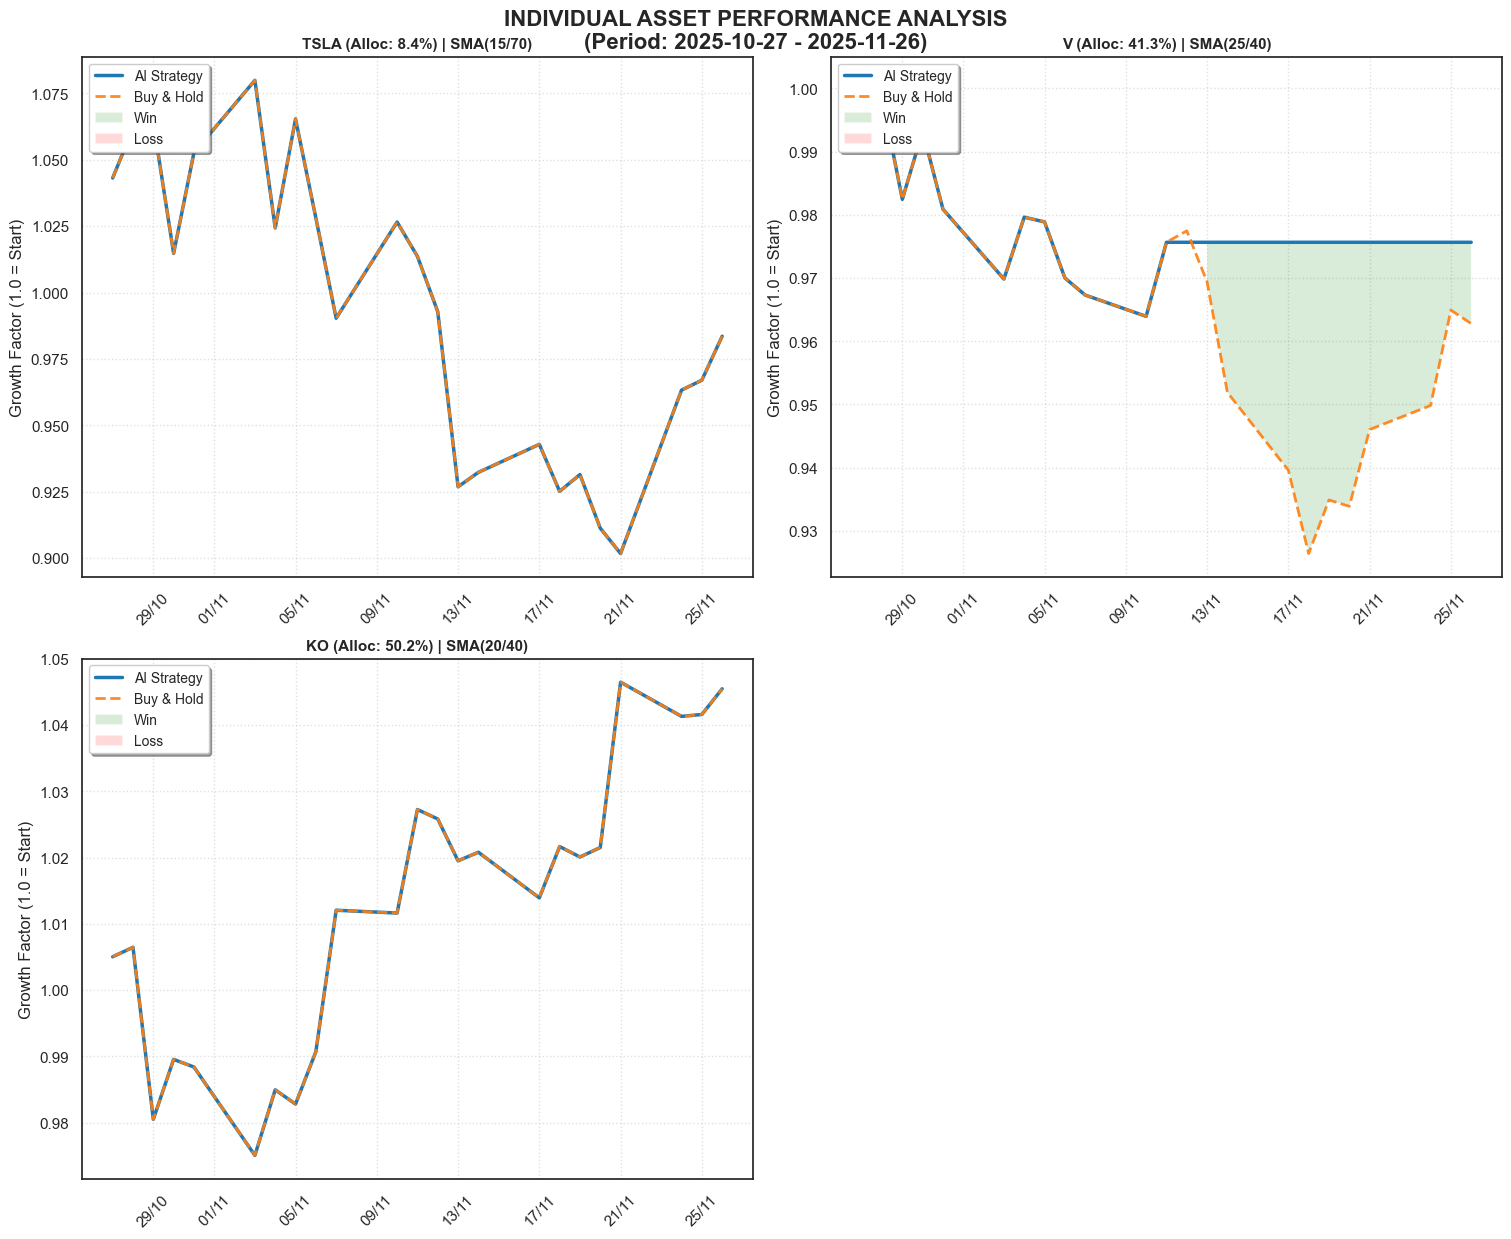

In [61]:
print(f"\n" + "="*80)
print(f" VISUALIZING INDIVIDUAL ASSET PERFORMANCE (TEST SET)")
print(f"="*80)

active_assets = [t for t, w in best_weights_train.items() if w > 0.001]
n_assets = len(active_assets)
n_cols = 2 
n_rows = math.ceil(n_assets / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6 * n_rows), constrained_layout=True)
axes = axes.flatten() 

max_lookback = 200 
train_buffer = train_data.iloc[-max_lookback:] 
for i, ticker in enumerate(active_assets):
    ax = axes[i]
    
    weight = best_weights_train[ticker]
    best_s, best_l = portfolio_best_params[ticker]
    
    df_part = pd.concat([train_buffer[[ticker]], test_data[[ticker]]])
    df = df_part.copy()
    
    df['Log_Ret'] = np.log(df[ticker] / df[ticker].shift(1)).fillna(0)
    df['SMA_S'] = df[ticker].rolling(window=best_s).mean()
    df['SMA_L'] = df[ticker].rolling(window=best_l).mean()
    df['Position'] = np.where(df['SMA_S'] > df['SMA_L'], 1, 0)
    df['Strategy_Ret'] = df['Position'].shift(1) * df['Log_Ret']
    df['Strategy_Ret'] = df['Strategy_Ret'].fillna(0)
    
    df_plot = df.loc[test_data.index].copy()
    cum_bnh = np.exp(df_plot['Log_Ret'].cumsum())     
    cum_strat = np.exp(df_plot['Strategy_Ret'].cumsum()) 
    
    # Visualization
    ax.plot(cum_strat, label=f'AI Strategy', color='#1f77b4', linewidth=2.5, zorder=3)
    ax.plot(cum_bnh, label='Buy & Hold', color='#ff7f0e', linestyle='--', linewidth=2, alpha=0.9, zorder=4)
    ax.fill_between(cum_strat.index, cum_strat, cum_bnh,
                    where=(cum_strat >= cum_bnh), facecolor='green', alpha=0.15, label='Win')
    ax.fill_between(cum_strat.index, cum_strat, cum_bnh,
                    where=(cum_strat < cum_bnh), facecolor='red', alpha=0.15, label='Loss')

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x', rotation=45) 
    ax.set_title(f"{ticker} (Alloc: {weight:.1%}) | SMA({best_s}/{best_l})", 
                 fontweight='bold', fontsize=11)
    ax.legend(loc='upper left', fontsize='small', frameon=True, shadow=True)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_ylabel('Growth Factor (1.0 = Start)')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f'INDIVIDUAL ASSET PERFORMANCE ANALYSIS\n(Period: {test_data.index.min().date()} - {test_data.index.max().date()})', 
             fontsize=16, fontweight='bold', y=1.02)

plt.show()

### 3.3 Full Simulation and Conclusion

Finally, this part use the trading strategy for each ticker


 PART 4: FULL HISTORY PORTFOLIO SIMULATION (TRAIN + TEST)
Simulation Config:
 > Period: 2023-09-01 -> 2025-11-26
 > Assets: ['TSLA', 'V', 'KO']
--------------------------------------------------------------------------------

>>> TRADE HISTORY FOR: TSLA (Last 5 trades)
      Date Symbol Type   Price      Value
2024-05-16   TSLA  BUY $174.84  $7,135.26
2025-02-13   TSLA SELL $355.94 $14,526.00
2025-05-13   TSLA  BUY $334.07 $14,526.00
2025-08-06   TSLA SELL $319.91 $13,910.30
2025-08-21   TSLA  BUY $320.11 $13,910.30

>>> TRADE HISTORY FOR: V (Last 5 trades)
      Date Symbol Type   Price      Value
2025-07-03      V SELL $357.52 $57,678.86
2025-09-17      V  BUY $345.52 $57,678.86
2025-10-03      V SELL $349.15 $58,285.30
2025-10-24      V  BUY $346.69 $58,285.30
2025-11-11      V SELL $338.25 $56,865.83

>>> TRADE HISTORY FOR: KO (Last 5 trades)
      Date Symbol Type  Price      Value
2025-04-10     KO  BUY $69.73 $66,724.26
2025-05-22     KO SELL $70.10 $67,082.58
2025-08-28     KO

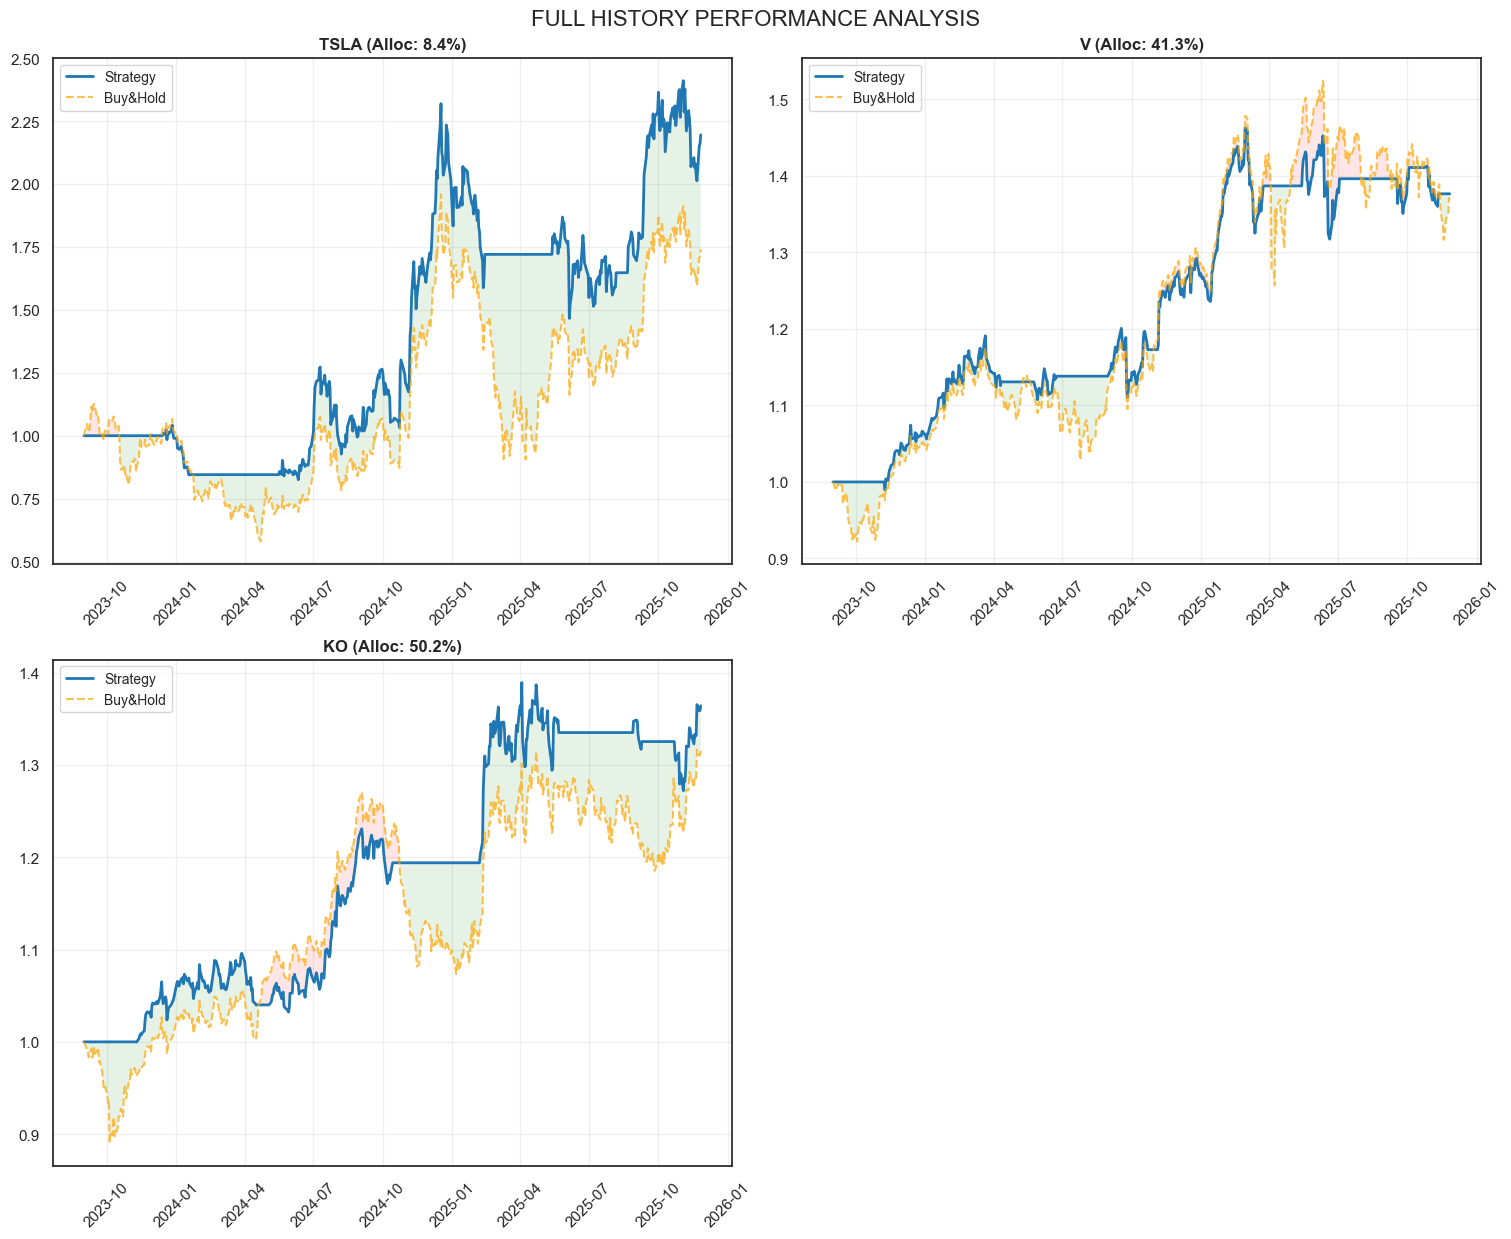


 FINAL PORTFOLIO SUMMARY
STARTING CAPITAL:  $100,000.00
ENDING VALUE:      $143,941.36
NET PROFIT:        $43,941.36
TOTAL RETURN:      +43.94%
--------------------------------------------------------------------------------


,Asset,SMA Config,Allocated,Final Equity,ROI
0,TSLA,(15/70),"$8,442.00","$18,536.92",+119.58%
1,V,(25/40),"$41,309.00","$56,865.83",+37.66%
2,KO,(20/40),"$50,249.00","$68,538.60",+36.40%



 MASTER TRADE LOG (ALL ASSETS CHRONOLOGICAL ORDER)


,Date,Symbol,Type,Price,Value
0,2023-11-07,V,BUY,$240.69,"$41,309.00"
0,2023-11-10,KO,BUY,$53.41,"$50,249.00"
0,2023-12-14,TSLA,BUY,$251.05,"$8,442.00"
1,2024-01-19,TSLA,SELL,$212.19,"$7,135.26"
1,2024-04-11,V,SELL,$272.17,"$46,711.57"
1,2024-04-16,KO,SELL,$55.55,"$52,260.39"
2,2024-05-03,KO,BUY,$59.48,"$52,260.39"
2,2024-05-16,TSLA,BUY,$174.84,"$7,135.26"
2,2024-05-24,V,BUY,$271.49,"$46,711.57"
3,2024-06-24,V,SELL,$273.28,"$47,019.59"


In [62]:
print(f"\n" + "="*80)
print(f" PART 4: FULL HISTORY PORTFOLIO SIMULATION (TRAIN + TEST)")
print(f"="*80)

INITIAL_PORTFOLIO_CAPITAL = 100000
total_ending_value = 0
portfolio_report = []
individual_results = {} 
all_trades_list = []

active_assets = [t for t, w in best_weights_train.items() if w > 0.001]
n_assets = len(active_assets)
n_cols = 2 
n_rows = math.ceil(n_assets / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6 * n_rows), constrained_layout=True)
axes = axes.flatten()

print(f"Simulation Config:")
print(f" > Period: {full_data.index.min().date()} -> {full_data.index.max().date()}")
print(f" > Assets: {active_assets}")
print("-" * 80)

for i, ticker in enumerate(active_assets):
    weight = best_weights_train[ticker]
    best_s, best_l = portfolio_best_params[ticker]
    allocated_capital = INITIAL_PORTFOLIO_CAPITAL * weight
    
    df_part = full_data[[ticker]].copy()
    
    bot = TradingBot(
        symbol=ticker,
        data=df_part,        
        sma_short=best_s,
        sma_long=best_l,
        initial_capital=allocated_capital
    )
    
    final_equity = bot.run_simulation()
    
    total_ending_value += final_equity
    roi = (final_equity - allocated_capital) / allocated_capital if allocated_capital > 0 else 0
    
    portfolio_report.append({
        'Asset': ticker, 'SMA Config': f"({best_s}/{best_l})",
        'Allocated': allocated_capital, 'Final Equity': final_equity, 'ROI': roi
    })
    
    if len(bot.trades) > 0:
        trade_df = pd.DataFrame(bot.trades)
        trade_df['Symbol'] = ticker 
        
        all_trades_list.append(trade_df)
        
        trade_df_print = trade_df.copy()
        trade_df_print['Date'] = trade_df_print['Date'].dt.date
        trade_df_print['Price'] = trade_df_print['Price'].map('${:,.2f}'.format)
        trade_df_print['Value'] = trade_df_print['Value'].map('${:,.2f}'.format)
        
        cols_order = ['Date', 'Symbol', 'Type', 'Price', 'Value']
        
        print(f"\n>>> TRADE HISTORY FOR: {ticker} (Last 5 trades)")
        print(trade_df_print[cols_order].tail(5).to_string(index=False))
    else:
        print(f"\n>>> {ticker}: No trades executed.")

    ax = axes[i]
    df_plot = df_part.copy()
    df_plot['Log_Ret'] = np.log(df_plot[ticker] / df_plot[ticker].shift(1)).fillna(0)
    df_plot['SMA_S'] = df_plot[ticker].rolling(best_s).mean()
    df_plot['SMA_L'] = df_plot[ticker].rolling(best_l).mean()
    df_plot['Pos'] = np.where(df_plot['SMA_S'] > df_plot['SMA_L'], 1, 0)
    df_plot['Strat_Ret'] = df_plot['Pos'].shift(1) * df_plot['Log_Ret']
    
    cum_bnh = np.exp(df_plot['Log_Ret'].cumsum())
    cum_strat = np.exp(df_plot['Strat_Ret'].fillna(0).cumsum())
    
    ax.plot(cum_strat, label='Strategy', color='#1f77b4', linewidth=2)
    ax.plot(cum_bnh, label='Buy&Hold', color='orange', linestyle='--', alpha=0.7)
    ax.fill_between(cum_strat.index, cum_strat, cum_bnh, where=(cum_strat >= cum_bnh), facecolor='green', alpha=0.1)
    ax.fill_between(cum_strat.index, cum_strat, cum_bnh, where=(cum_strat < cum_bnh), facecolor='red', alpha=0.1)
    
    ax.set_title(f"{ticker} (Alloc: {weight:.1%})", fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(loc='upper left', fontsize='small')
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
plt.suptitle(f'FULL HISTORY PERFORMANCE ANALYSIS', fontsize=16, y=1.02)
plt.show()

print(f"\n" + "="*80)
print(f" FINAL PORTFOLIO SUMMARY")
print(f"="*80)
total_roi = (total_ending_value - INITIAL_PORTFOLIO_CAPITAL) / INITIAL_PORTFOLIO_CAPITAL

print(f"STARTING CAPITAL:  ${INITIAL_PORTFOLIO_CAPITAL:,.2f}")
print(f"ENDING VALUE:      ${total_ending_value:,.2f}")
print(f"NET PROFIT:        ${total_ending_value - INITIAL_PORTFOLIO_CAPITAL:,.2f}")
print(f"TOTAL RETURN:      {total_roi:+.2%}")
print("-" * 80)

summary_df = pd.DataFrame(portfolio_report)
summary_df['Allocated'] = summary_df['Allocated'].map('${:,.2f}'.format)
summary_df['Final Equity'] = summary_df['Final Equity'].map('${:,.2f}'.format)
summary_df['ROI'] = summary_df['ROI'].map('{:+.2%}'.format)
display(summary_df)
if all_trades_list:
    print(f"\n" + "="*80)
    print(f" MASTER TRADE LOG (ALL ASSETS CHRONOLOGICAL ORDER)")
    print(f"="*80)
    
    master_df = pd.concat(all_trades_list)
    master_df.sort_values(by='Date', inplace=True)
    
    master_df_print = master_df.copy()
    master_df_print['Date'] = master_df_print['Date'].dt.date
    master_df_print['Price'] = master_df_print['Price'].map('${:,.2f}'.format)
    master_df_print['Value'] = master_df_print['Value'].map('${:,.2f}'.format)
    
    cols_order = ['Date', 'Symbol', 'Type', 'Price', 'Value']
    display(master_df_print[cols_order])